# **Data Analysis :**

In [1]:
# #! ALL Python modules imported here.
import cv2
import h5py
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,Dataset
import os
from torchvision import transforms
from PIL import Image
import random
from torch.nn import functional as F
import torchvision
from torchmetrics.image import TotalVariation

import json

In [3]:

VGG19=torchvision.models.vgg19(torchvision.models.VGG19_Weights.IMAGENET1K_V1)
vgg19_feature_extractor=VGG19.features[:35]

In [50]:
# #! ALL utilities Here :

# #* Single channels images :
def show_MRI_IMAGES_C(image:np.array):

    fig,axes=plt.subplots(2,2,figsize=(20,20))
    axes=axes.flatten()
    fig.align_titles()
    for c in range(4):
        axes[c].imshow((image[:,:,c]+1)/2)
        axes[c].set_title(f"Image (240x240x4) channel : {c}")
        axes[c].axis('off')

    plt.tight_layout()
    plt.show()
    return

# * Save Dataset Functions :
def save_dataset(dataset_name:str,fold_list: list,src:str,dest:str):

    dataset_path=f'{dest}/{dataset_name}'

    os.makedirs(dataset_path,exist_ok=True)

    for fold in fold_list:

        src_folder_path=f'{src}/{fold}'

        dest_folder_path=f'{dataset_path}/{fold}'

        os.makedirs(dest_folder_path,exist_ok=True)

        for file in os.listdir(src_folder_path):

            src_file_path=f'{src_folder_path}/{file}'
            
            dest_file_path=f'{dest_folder_path}/{file}'

            with h5py.File(src_file_path,'r') as f:

                image=f['image'][:]
            
            with h5py.File(dest_file_path,'w') as f:

                f.create_dataset('image',data=image)

    return  True


# * Show the MRI Images :
def show_MRI_images(image1:np.array,image2:np.array,title1:str,title2: str):
    plt.figure()
    image1,image2=np.array(image1),np.array(image2)
    fig,axes=plt.subplots(1,2,figsize=(20,20))
    axes=axes.flatten()

    
    up_size=image1.shape[0]*4
    axes[0].imshow(upscale_image(image1,up_size,up_size),cmap='gray')
    axes[0].set_title(f'{title1}')
    axes[0].axis('off')

    axes[1].imshow(image2,cmap='gray')
    axes[1].set_title(f'{title2}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    



#* upscale the images to (H,W) dimension

def upscale_image(image: np.array ,H:int,W:int):

    image=np.array(image)

    image=cv2.resize(
        image,
        (H,W),
        interpolation=cv2.INTER_CUBIC
    )
    
    return image



#* Gaussian noise function add to images 

def AddGaussianNoise(image: np.array ,mean:int=0 ,std:int=1):

    #* note input image in the -1 to 1 so we have denormalize it.
    image=(image+1)/2
    noise=np.random.normal(mean,std,image.shape)

    image=image+noise

    #* note input image in the -1 to 1 so we have normalize it again.
    image=(image*2-1)

    return image
    

#* function to on/off the model parameter updating
def ON_OFF_Grad(model:torch.nn.Module,switch:str):

    for layer in model.parameters():
        if switch.upper() =='ON':
            layer.requires_grad=True
        else:
            layer.requires_grad=False


#* it save the images to specified location.
def save_MRI_images(image1:np.array,image2:np.array,image3:np.array,title1:str,title2: str,title3:str,image_name:str,fold: str):

    os.makedirs(fold,exist_ok=True)

    plt.figure()
    image1,image2,image3=np.array(image1),np.array(image2),np.array(image3)
    fig,axes=plt.subplots(1,3,figsize=(20,20))
    axes=axes.flatten()
    up_size=image1.shape[0]*4
    axes[0].imshow(upscale_image(image1,up_size,up_size),cmap='gray')
    axes[0].set_title(f'{title1}')
    axes[0].axis('off')

    axes[1].imshow(image2,cmap='gray')
    axes[1].set_title(f'{title2}')
    axes[1].axis('off')

    axes[2].imshow(image3,cmap='gray')
    axes[2].set_title(f'{title3}')
    axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f"./{fold}/{image_name}.png",dpi=300,bbox_inches='tight')
    plt.close()
    return


# **Dataset and Dataloader :**

In [5]:
class RIRGAN_Dataset(Dataset):

    def __init__(self,dataset_path: str,size:int,add_noise: bool,mean:int=0,std:int=0.0005):
        
        super().__init__()
        
        self.all_files=list()
        self.size=size
        self.add_noise=add_noise
        self.mean=mean
        self.std=std

        for vol in os.listdir(dataset_path):

            vol_fold_path=f'{dataset_path}/{vol}'
            for file in os.listdir(vol_fold_path):
                
                file_path=f'{vol_fold_path}/{file}'
                self.all_files.append(file_path)


    def __len__(self):
        
        return len(self.all_files)


    def __getitem__(self, index):
        
        file_path= self.all_files[index]

        with h5py.File(file_path,'r') as f:

            image=f['image'][:]
        
        
        offset_x_list=list(range(-12,20))
        offset_y_list=list(range(-12,16))

        # offset_x=random.choice(offset_x_list)
        # offset_y=random.choice(offset_y_list)

        offset_x=20
        offset_y=0

        H,W,_=image.shape
        
        center_x=W//2
        center_y=H//2
        
        image=image[:,:,1] #* index=1 then Te(Enhanced Tumor)

        #^ cropping the images to generate the HR Path:
        size=self.size//2
        img_hr=image[ center_y-size+offset_y :center_y+size+offset_y , center_x-size+offset_x : center_x+size+offset_x ]
        # img_hr=image[ center_y-size:center_y+size , center_x-size : center_x+size ]
        # img_hr=(img_1+1)/2 #* denormalazation

        hr_image_noise=AddGaussianNoise(img_hr.copy(),mean=self.mean,std=self.std)

        lr_image=cv2.resize(hr_image_noise,(self.size//4,self.size//4),interpolation=cv2.INTER_CUBIC)
        
        
        lr_image=torch.tensor(lr_image).float().reshape((1,self.size//4,self.size//4))
        hr_image=torch.tensor(img_hr).float().reshape((1,self.size,self.size))


        return lr_image,hr_image

    


In [ ]:
128//4

32

In [6]:
# #! Dataset Path :
train_dataset_path='./data/train'
test_dataset_path='./data/test'
val_dataset_path='./data/val'

In [7]:
size=96 #* HR images W/H
train_dataset=RIRGAN_Dataset(train_dataset_path,size,add_noise=True)
print(f'Training LR Images Shape :{train_dataset.__getitem__(0)[0].shape}')
print(f'Training HR Images Shape :{train_dataset.__getitem__(0)[1].shape}')
LR_image,HR_image=train_dataset.__getitem__(1)[0],train_dataset.__getitem__(1)[1]

Training LR Images Shape :torch.Size([1, 24, 24])
Training HR Images Shape :torch.Size([1, 96, 96])


In [8]:
upscale_image(train_dataset.__getitem__(0)[0][0],size,size)

array([[ 1.5126766 ,  1.525464  ,  1.5882314 , ...,  2.440795  ,
         2.4534724 ,  2.4569168 ],
       [ 1.5187656 ,  1.5309153 ,  1.5904642 , ...,  2.4488428 ,
         2.4580946 ,  2.4608815 ],
       [ 1.548888  ,  1.5579726 ,  1.6020893 , ...,  2.4868011 ,
         2.4792008 ,  2.4787474 ],
       ...,
       [-0.40671906, -0.3188395 ,  0.08497839, ...,  2.1876402 ,
         2.1186664 ,  2.1055634 ],
       [-0.7651995 , -0.6641309 , -0.20009126, ...,  2.0381298 ,
         1.952929  ,  1.9365307 ],
       [-0.84432936, -0.7403728 , -0.26313433, ...,  2.0059507 ,
         1.9172837 ,  1.9001807 ]], dtype=float32)

<Figure size 640x480 with 0 Axes>

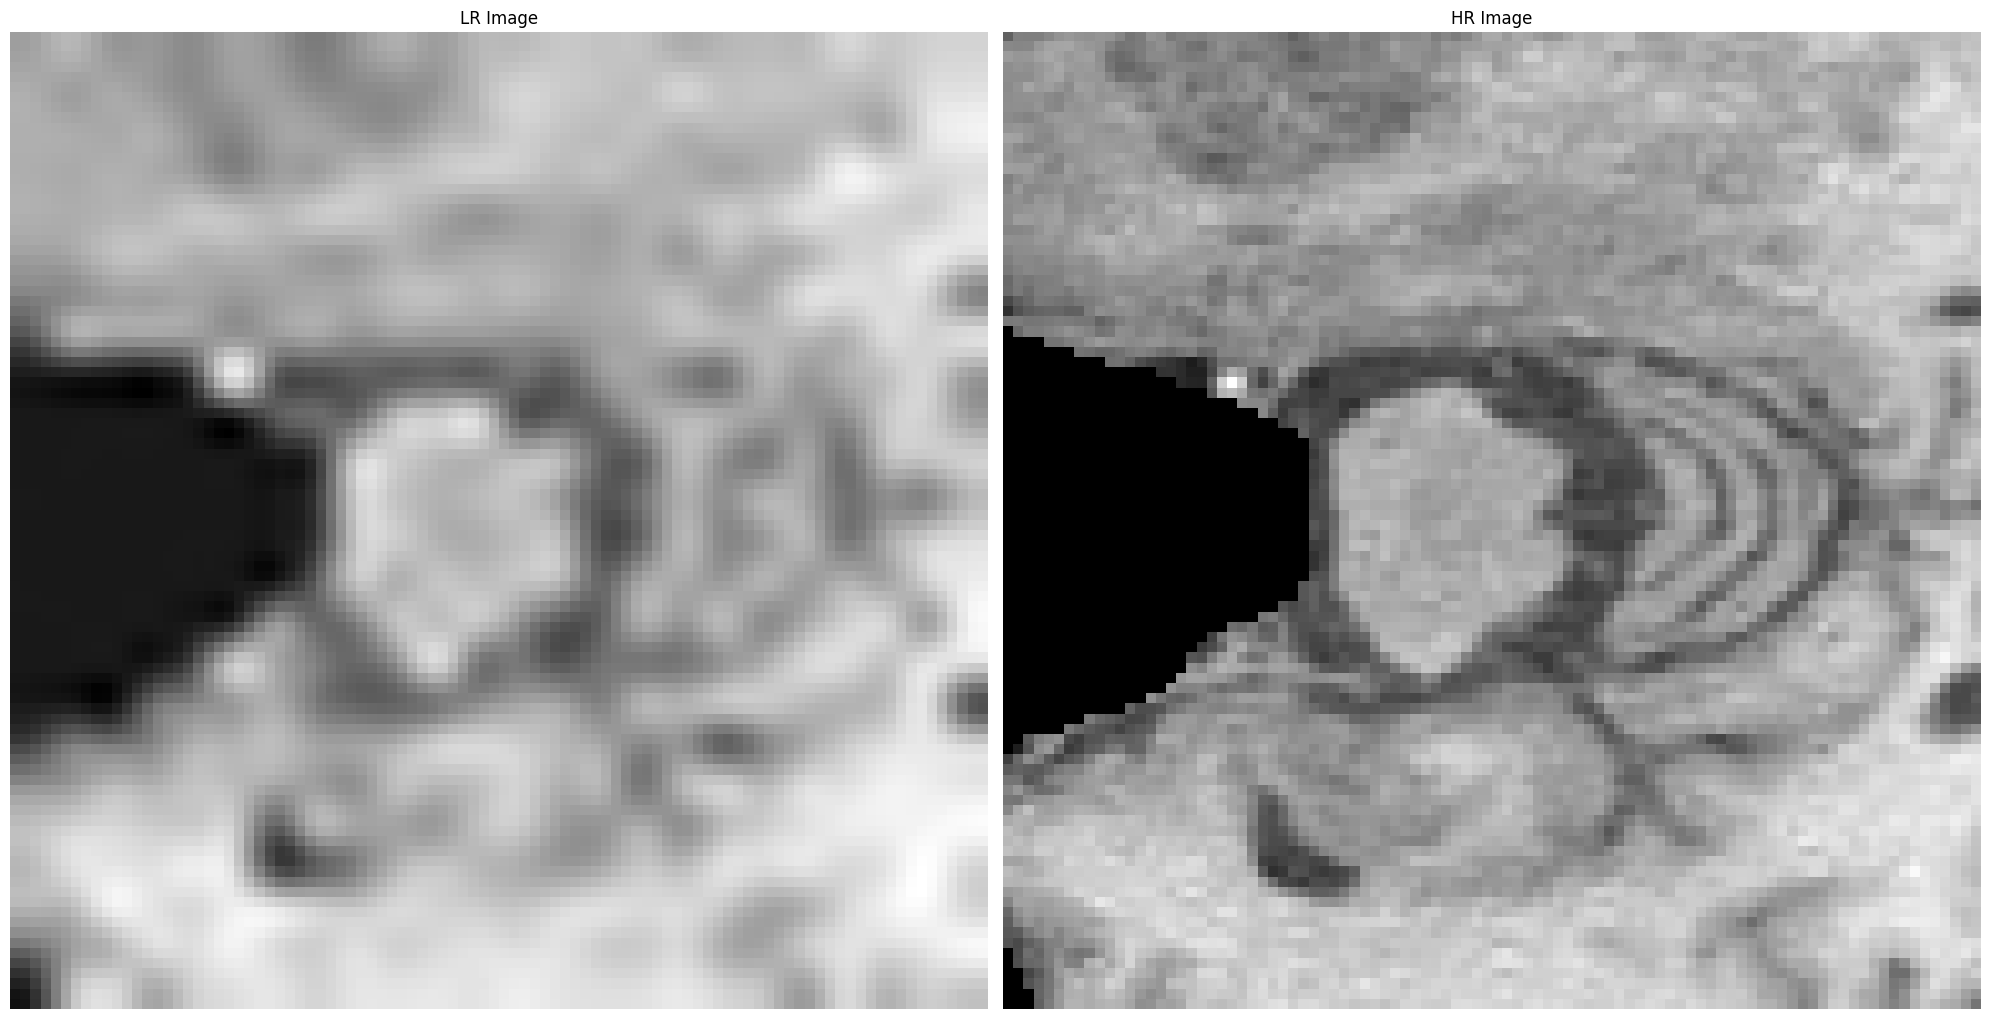

In [9]:
show_MRI_images(
    image1=upscale_image((LR_image[0]+1)/2,size,size),
    image2=(HR_image[0]+1)/2,
    title1='LR Image',
    title2='HR Image'
)

<Figure size 640x480 with 0 Axes>

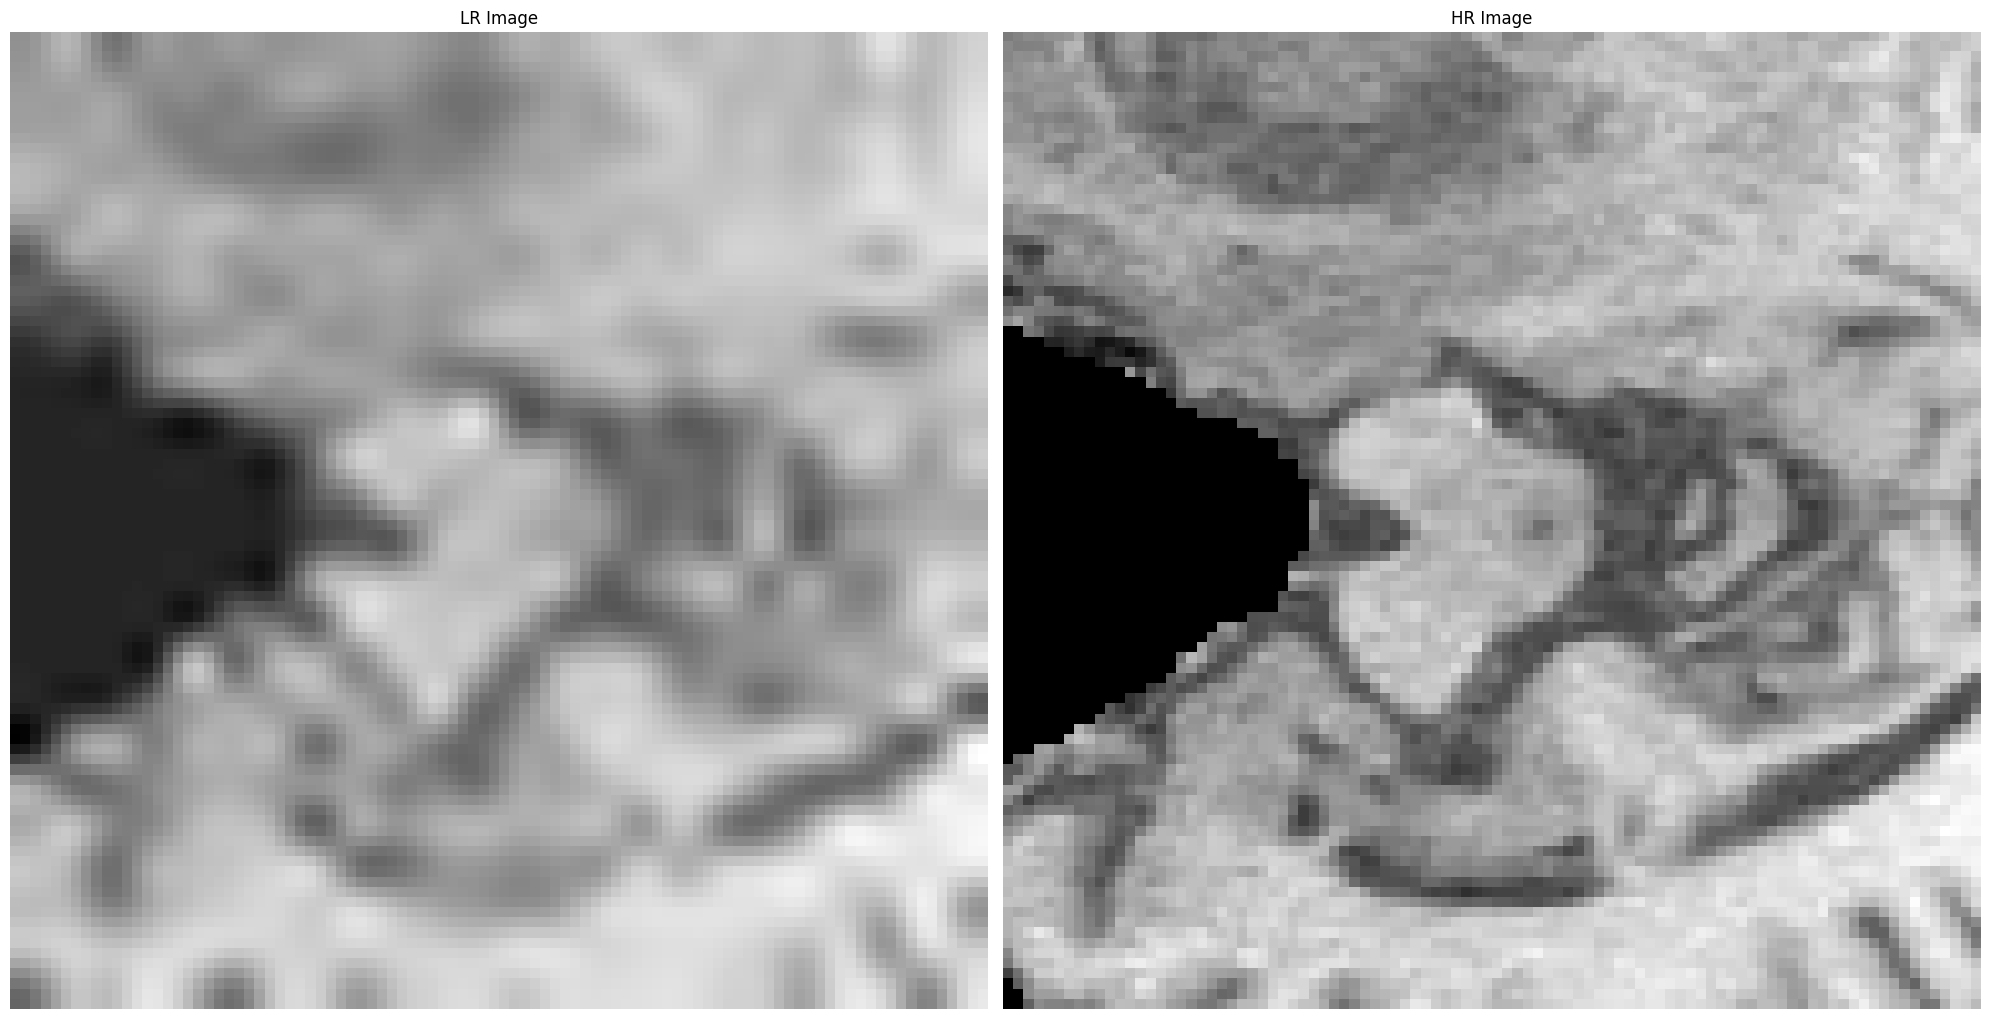

In [10]:
show_MRI_images(
    image1=upscale_image(train_dataset.__getitem__(6)[0][0],size,size),
    image2=train_dataset.__getitem__(6)[1][0],
    title1='LR Image',
    title2='HR Image'
)

In [11]:
upscale_image(AddGaussianNoise(LR_image)[0],size,size).shape

(96, 96)

<Figure size 640x480 with 0 Axes>

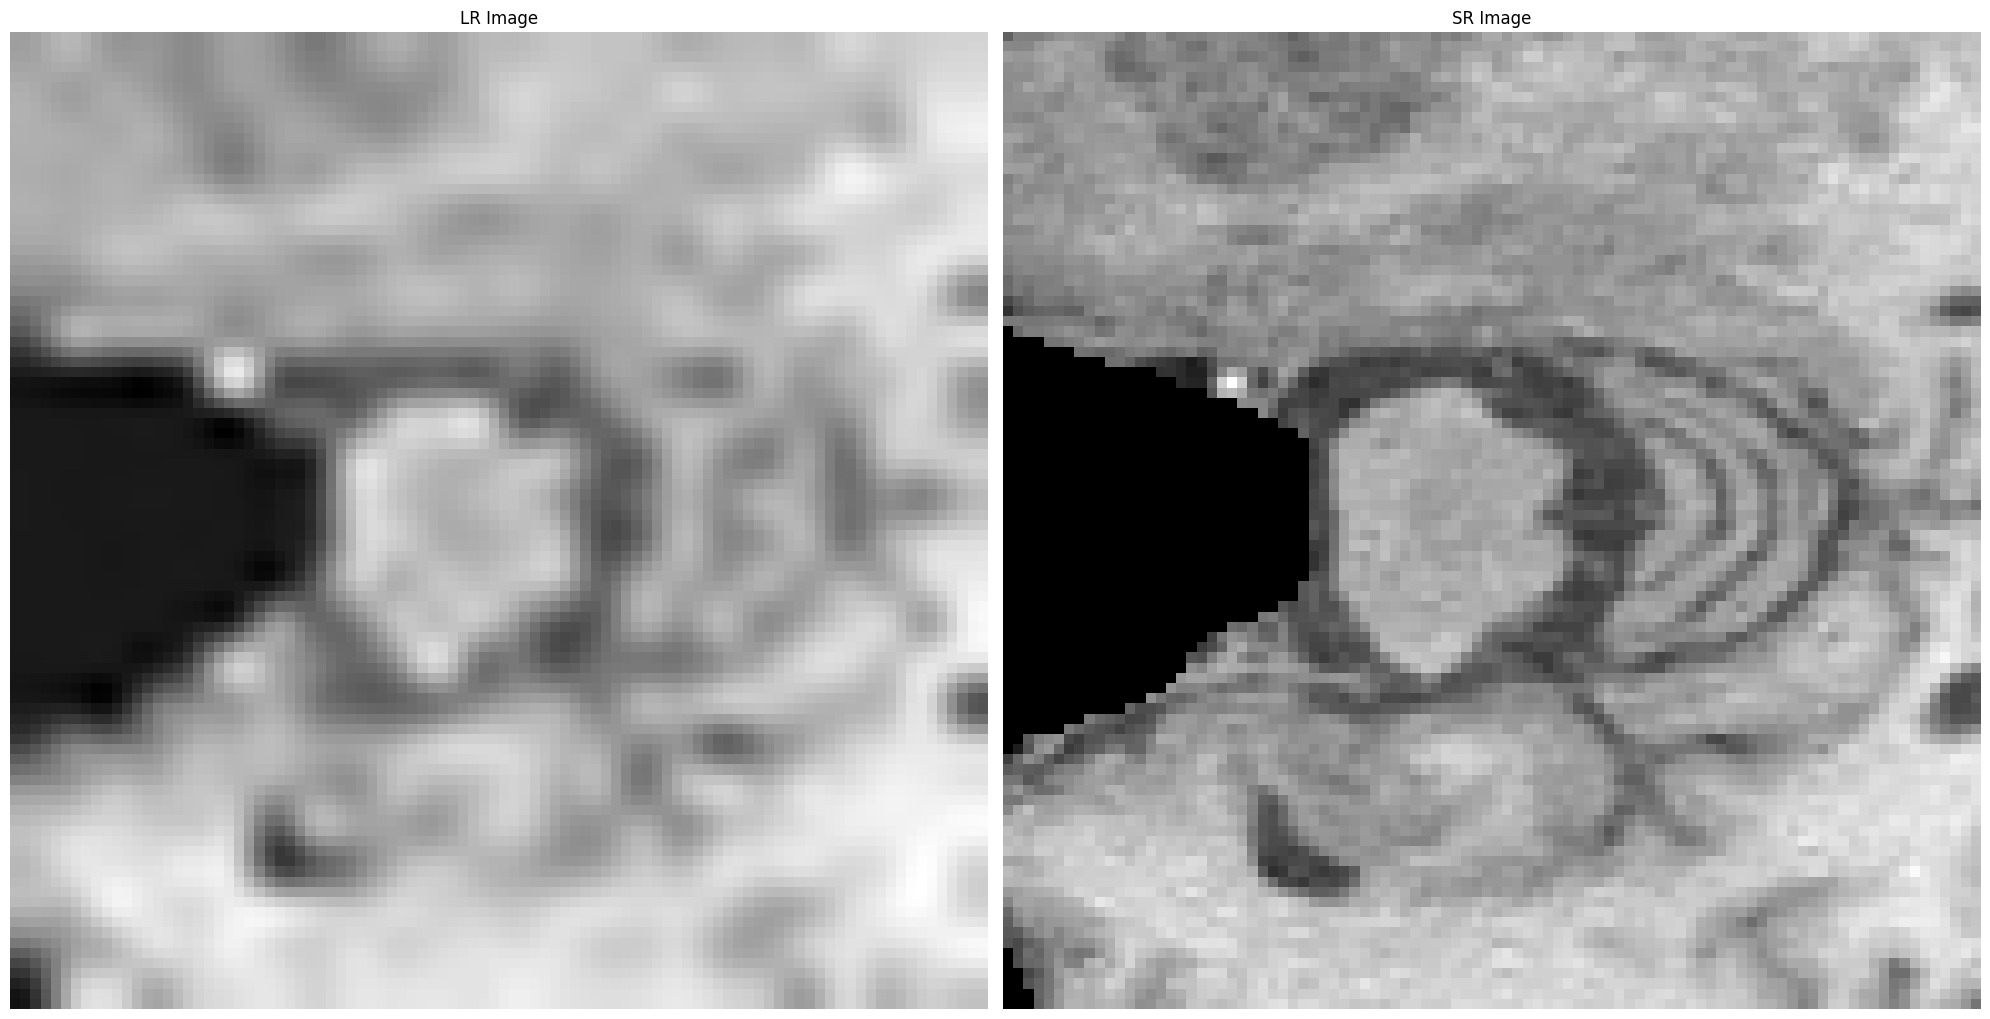

In [12]:
show_MRI_images(
    image1=upscale_image(AddGaussianNoise(LR_image,mean=0,std=0.005)[0],size,size),
    image2=HR_image[0],
    title1='LR Image',
    title2="SR Image"
)

In [44]:
# #! Dataset Path :
train_dataset_path='./data/train'
test_dataset_path='./data/test'
val_dataset_path='./data/val'

train_val_size=96
test_size=128
batch_size=16

train_dataset=RIRGAN_Dataset(train_dataset_path,train_val_size,add_noise=True)
val_dataset=RIRGAN_Dataset(val_dataset_path,train_val_size,add_noise=True)

test_dataset=RIRGAN_Dataset(test_dataset_path,test_size,add_noise=True)


test_dataset.__getitem__(0)[0].shape

torch.Size([1, 32, 32])

# **DataLoader :**

In [45]:
# #* DataLoader :
batch_size=16 #* from the paper


train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)

In [46]:
# #* testing the dataloader

print(f'Total Batch in Training : {len(train_loader)}')
print(f'Total Batch in Validation : {len(val_loader)}')
print(f'Total Batch in Testing : {len(test_loader)}')

Total Batch in Training : 469
Total Batch in Validation : 58
Total Batch in Testing : 51


In [47]:
LR_Images,HR_Images=next(iter(test_loader))

print(f'LR Images Shape :{LR_Images.shape}')
print(f'HR Images Shape :{HR_Images.shape}')

LR Images Shape :torch.Size([16, 1, 32, 32])
HR Images Shape :torch.Size([16, 1, 128, 128])


<Figure size 640x480 with 0 Axes>

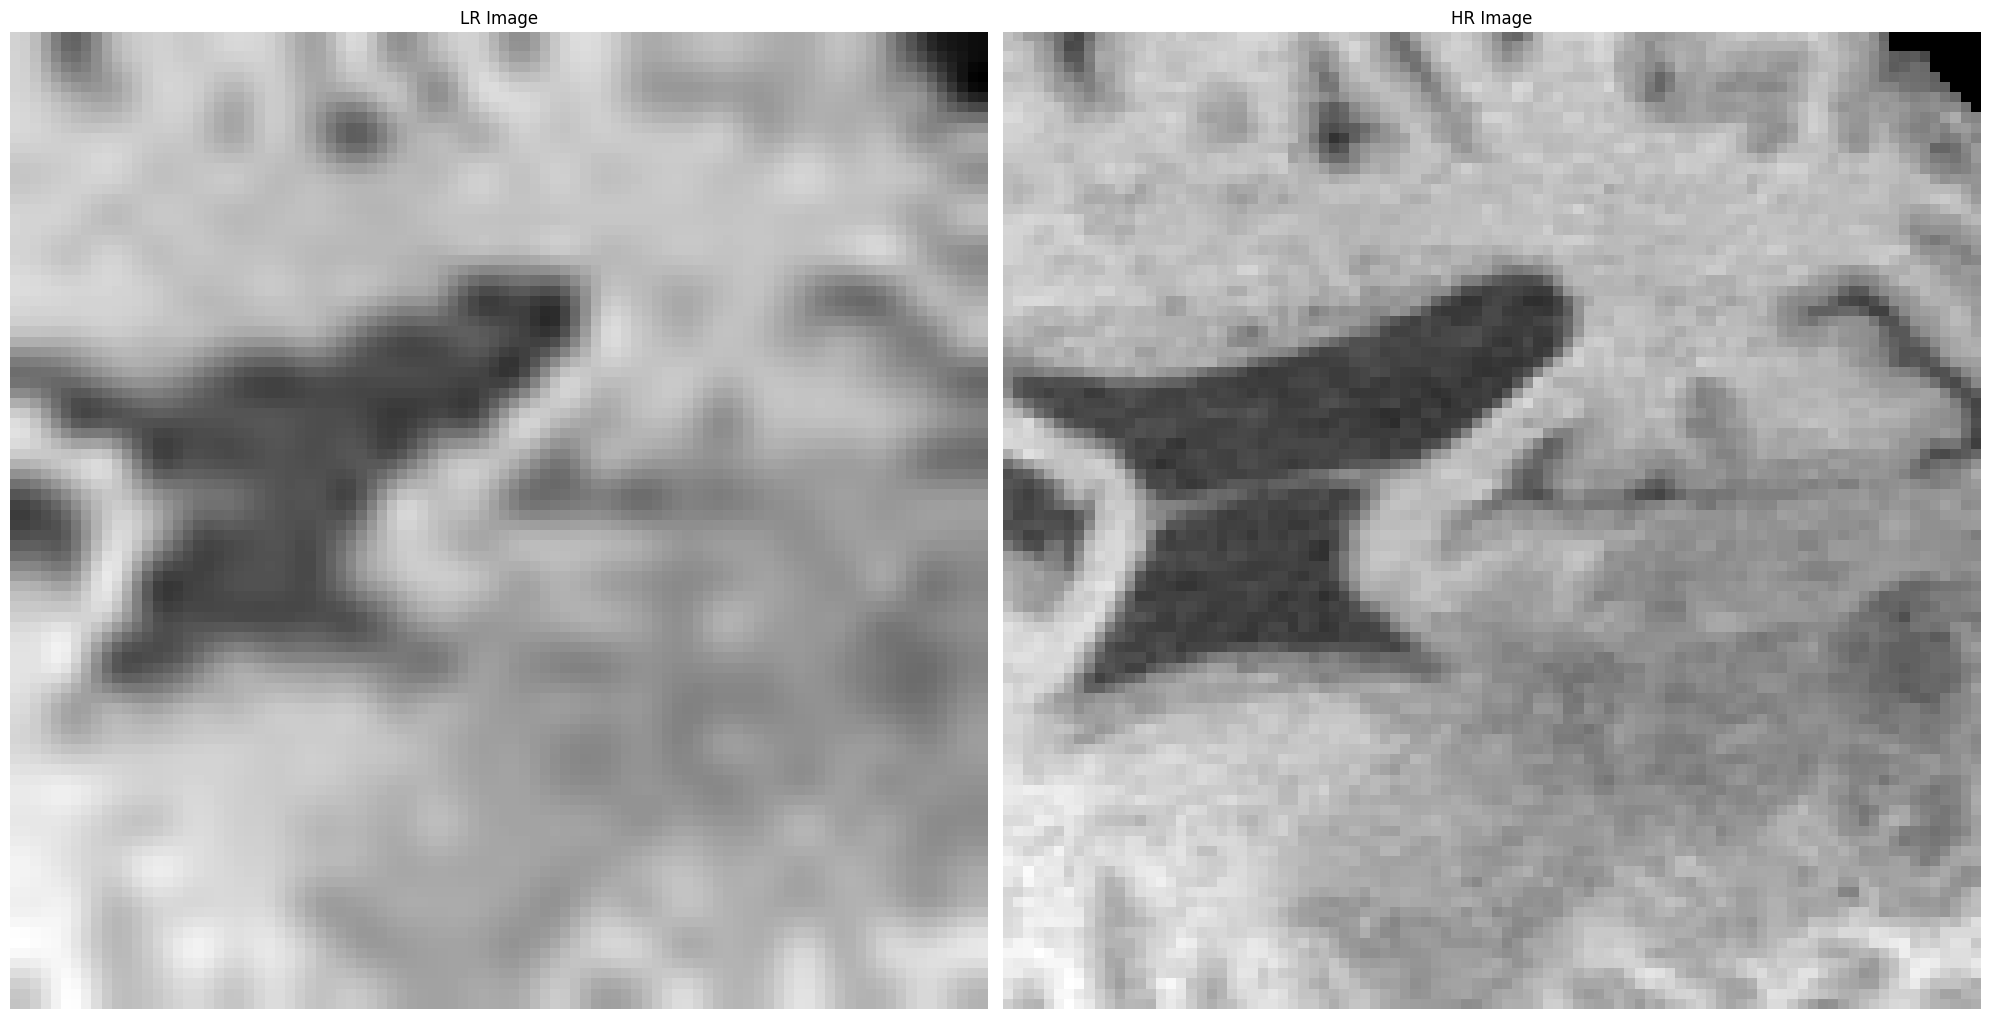

In [17]:
show_MRI_images(
    upscale_image(LR_Images[0][0],train_val_size,train_val_size),
    HR_Images[0][0],
    "LR Image",
    "HR Image"
)

# **Model Architecture :**

## **1.Enhanced Residual Block :**

In [18]:
class EResidualBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int ):
        super().__init__()

        self.conv1=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.PRelu=nn.PReLU()

        self.conv2=nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        

    def forward(self,inputs):

        output=self.conv1(inputs)

        output=self.PRelu(output)

        output=self.conv2(output)

        output=output+inputs  #* Here output and input should have the same dimension

        return output



## **2.RIR-Block :**

In [19]:
class RIRBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels: int ,kernel_size:int,num_of_ERes_block:int,alpha:int):
        super().__init__()
        self.alpha=alpha
        self.RIR_Block=nn.Sequential(
            *[
                EResidualBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size
                )
                for _ in range(num_of_ERes_block)
            ]
        )

    def forward(self,inputs):

        output=self.RIR_Block(inputs)

        output=inputs + (self.alpha) * output

        return output

## **3.SubPixelLayer :**

In [ ]:
class SubPixelLayer(nn.Module):
    def __init__(self,in_channels:int,out_channels:int,kernel_size:int,scale:int):

        super().__init__()
        
        self.conv=nn.Conv2d(
            in_channels=in_channels, #* 64
            out_channels=out_channels, #* 256
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.pixelShuffler=nn.PixelShuffle(upscale_factor=scale) #* it enlarge the input image in height and weight by putting the missing pixel from the higher subpixel space 

        self.PRelu=nn.PReLU()
        

    def forward(self,inputs):

        output=self.conv(inputs)

        output=self.pixelShuffler(output)

        output=self.PRelu(output)

        return output



## **4.RIRG-Input Layer :**

In [21]:
class RIRGInputLayer(nn.Module):

    def __init__(self, in_channels:int,out_channels: int,kernel_size: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.PRelu=nn.PReLU()

    def forward(self,inputs):
        
        output=self.conv(inputs)
        output=self.PRelu(output)
        return output


## **5.RIRG-Output Layer :**

In [ ]:
class RIRGOutputLayer(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding='same',
            stride=1
        )

        self.tanh=nn.Tanh()

    
    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.tanh(output)
        
        return output

In [23]:
class RIRG(nn.Module):

    def __init__(self,in_channel:int,out_channel:int,in_RIR_block_channel:int,
                kernel_size_in_out_layer:int,kerne_size_RIR_block:int,no_of_RIR_Block:int,no_of_ERes_block:int,
                sub_PixelLayer_channel:int,alpha:int,scale:int):
        super().__init__()

        self.inputLayer=RIRGInputLayer(
            in_channels=in_channel,
            out_channels=in_RIR_block_channel,
            kernel_size=kernel_size_in_out_layer
        )

        self.FeatureExtractionLayer=nn.Sequential(
            *[
                RIRBlock(
                    in_channels=in_RIR_block_channel,
                    out_channels=in_RIR_block_channel,
                    kernel_size=kerne_size_RIR_block,
                    num_of_ERes_block=no_of_ERes_block,
                    alpha=alpha
                )
                for _ in range(no_of_RIR_Block)
            ]
        )

        self.conv=nn.Conv2d(
            in_channels=in_RIR_block_channel,
            out_channels=in_RIR_block_channel,
            kernel_size=kerne_size_RIR_block,
            padding='same',
            stride=1
        )

        self.SubPixelLayer1=SubPixelLayer(
            in_channels=in_RIR_block_channel,
            out_channels=sub_PixelLayer_channel,
            kernel_size=kerne_size_RIR_block,
            scale=scale
        )
        self.SubPixelLayer2=SubPixelLayer(
            in_channels=in_RIR_block_channel,
            out_channels=sub_PixelLayer_channel,
            kernel_size=kerne_size_RIR_block,
            scale=2
        )

        self.OutputLayer=RIRGOutputLayer(
            in_channels=in_RIR_block_channel,
            out_channels=out_channel,
            kernel_size=kernel_size_in_out_layer
        )

    def forward(self,inputs):
        
        #* input layer
        out_inputLayer=self.inputLayer(inputs)

        #* feature extraction layer :

        out_featureExtra_layer=self.FeatureExtractionLayer(out_inputLayer)

        #* conv layer :

        out_conv_layer=self.conv(out_featureExtra_layer)

        #* Global Residual connection : (GSC-Global Skip Connection)

        out_GSC=out_conv_layer+out_inputLayer

        #* Sub Pixel Layer(Enlarge Layer)

        out_pixel_layer1=self.SubPixelLayer1(out_GSC)
        out_pixel_layer2=self.SubPixelLayer2(out_pixel_layer1)

        #* Output Layer (Regenerator Layer)

        output=self.OutputLayer(out_pixel_layer2)

        return output


In [23]:
# test=RIRG(
#     in_channel=1,
#     out_channel=1,
#     in_RIR_block_channel=64,
#     kernel_size_in_out_layer=9,
#     kerne_size_RIR_block=3,
#     no_of_RIR_Block=8,
#     no_of_ERes_block=5,
#     sub_PixelLayer_channel=256,
#     alpha=0.2,
#     scale=2   
# )

# test(LR_Images).shape

# **RaD-Discriminator :**

## **1. RaDInput Layer :**

In [24]:
class RadInputLayer(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=1,
            padding='same'
        )

        self.LRelu=nn.LeakyReLU()
    


    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.LRelu(output)

        return output

## **2.RaDRepeat Block :**

In [25]:
class RadRepeatBlock(nn.Module):

    def __init__(self,in_channels:int,out_channels:int,kernel_size:int ,stride: int):
        super().__init__()

        self.conv=nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride
        )

        self.BNLayer=nn.BatchNorm2d(
            num_features=out_channels,
        )

        self.LRelu=nn.LeakyReLU()
    
    def forward(self,inputs):
        
        output=self.conv(inputs)

        output=self.BNLayer(output)

        output=self.LRelu(output)

        return output

## **3.Output Layer :**

In [26]:
class RadOutputLayer(nn.Module):

    def __init__(self,in_features_1:int,out_features_1:int,out_features_2:int,bias: bool = False ):
        super().__init__()

        self.Dense1=nn.Linear(
            in_features=in_features_1,
            out_features=out_features_1,
            bias=bias,
        )

        self.LRelu=nn.LeakyReLU()

        self.Dense2=nn.Linear(
            in_features=out_features_1,
            out_features=out_features_2,
            bias=bias
        )
    
    def forward(self,inputs):

        output=self.Dense1(inputs)

        output=self.LRelu(output)

        output=self.Dense2(output)
        
        return output


## **4.RaD :**

In [27]:
class Rad(nn.Module):

    def __init__(self,params: dict ):
        super().__init__()

        self.InputLayer=RadInputLayer(
            in_channels=params['input_layer']['input_channel'],
            out_channels=params['input_layer']['num_of_channels'],
            kernel_size=params['input_layer']['k']
            
        )

        self.InnerLayer=nn.Sequential(
            *[
                RadRepeatBlock(
                    in_channels=param['input_channel'],
                    out_channels=param['num_of_channels'],
                    kernel_size=param['k'],
                    stride=param['stride']
                )
                for  ind,(name,param) in enumerate(params.items()) if ind in range(1,8)
            ]
        )

        self.FlattenLayer=nn.Flatten()

        self.OutPutLayer=RadOutputLayer(
            in_features_1=params['RadOutput']['input_features_1'],
            out_features_1=params['RadOutput']['output_features_1'],
            out_features_2=params['RadOutput']['output_features_2']
        )

    
    def forward(self,inputs):
        

        output=self.InputLayer(inputs)
        output=self.InnerLayer(output)
        output=self.FlattenLayer(output)
        output=self.OutPutLayer(output)

        return  output



In [28]:
params={
    'input_layer':{
        'input_channel':1,
        'k':3,
        'num_of_channels':64,
        'stride':1
    },
    'Rad_Repeat_block1':{
        'input_channel':64,
        'k':3,
        'num_of_channels':64,
        'stride':2
    },
    'Rad_Repeat_block2':{
        'input_channel':64,
        'k':3,
        'num_of_channels':128,
        'stride':1
    },
    'Rad_Repeat_block3':{
        'input_channel':128,
        'k':3,
        'num_of_channels':128,
        'stride':2
    },
    'Rad_Repeat_block4':{
        'input_channel':128,
        'k':3,
        'num_of_channels':256,
        'stride':1
    },
    'Rad_Repeat_block5':{
        'input_channel':256,
        'k':3,
        'num_of_channels':256,
        'stride':2
    },
    'Rad_Repeat_block6':{
        'input_channel':256,
        'k':3,
        'num_of_channels':512,
        'stride':1
    },
    'Rad_Repeat_block7':{
        'input_channel':512,
        'k':3,
        'num_of_channels':512,
        'stride':2
    },
    'RadOutput':{
        'input_features_1':4608,
        'output_features_1':1024,
        'output_features_2':1,
    },
}

In [3]:
# test=Rad(params)

# test(HR_Images)

# **Training Process :**

# **1.Define All Losses :**

## **A) RaD Loss :**

In [29]:
def RaDLossFun(HR_Output:torch.Tensor,SR_Output:torch.Tensor ,device:torch.device='cpu'):

    #* Mean values :
    avg_sr_output=SR_Output.mean()
    avg_hr_output=HR_Output.mean()

    #* finding the relative score :

    relative_real_fake=HR_Output-avg_sr_output
    relative_fake_real=SR_Output-avg_hr_output


    # loss=((-1*(relative_real_fake.log() + (1-relative_fake_real).log())).sum())/HR_Output.shape[0]
    
    #* RaD want to increase the relative_real_fake ie . how much real image look real than fake
    loss_real=F.binary_cross_entropy_with_logits(
        input=relative_real_fake,
        target=torch.ones_like(HR_Output).to(device) #^ therefor it is one ie. avg(log(relative_real_fake))
    )

    #* RaD want to decrease the relative_fake_real ie. how much fake image look to real relative to real.
    loss_fake=F.binary_cross_entropy_with_logits(
        input=relative_fake_real,
        target=torch.zeros_like(SR_Output).to(device) #^ therefor it is zero  ie. avg(log(1-relative_fake_real))
    )



    return (loss_real+loss_fake)
    

## **B) Generator Loss :**

### **1.Adversarial Loss :**
    **1.Goal of this loss to Make the Model to generate the Fake Image Look to Real**
    **2.In Mathematically : Decrease the avg diff between real and fake**

In [30]:
def RIRGAdversarialLoss(HR_Output:torch.Tensor,SR_Output:torch.Tensor,device:torch.device = 'cpu'):

    #* Mean values :
    avg_hr_output=HR_Output.mean()
    avg_sr_output=SR_Output.mean()

    #* finding the relative score :

    relative_real_fake=HR_Output-avg_sr_output
    relative_fake_real=SR_Output-avg_hr_output

    #* loss

    # loss=((((1-relative_real_fake).log() + relative_fake_real.log()) * -1).sum())/HR_Output.shape[0]

    #* loss real

    #^ generator want to generate more realistic images so ie. is have to decrease relative_real_fake ie. fake images look like real images :
    loss_real=F.binary_cross_entropy_with_logits(
        input=relative_real_fake,
        target=torch.zeros_like(HR_Output).to(device)  #^ ie. avg(log(1-relative_real_fake)) ↑↑↑↑↑
    )

    #* loss fake
    #^ generate want to generate fake image looks real so it have to increase relative_fake_real ie.
    loss_fake=F.binary_cross_entropy_with_logits(
        input=relative_fake_real,
        target=torch.ones_like(SR_Output).to(device) #^ ie. avg(log(relative_fake_real))  ↑↑↑↑↑
    )


    return (loss_real+loss_fake)



### **2.Pixel Loss :**
    -it is Mean Absolute Difference between the two pixel of SR and HR.
    -it help to gain the structure and reduce the loss.

In [31]:

def RIRPixelLoss(HR_Images:torch.Tensor,SR_Images:torch.Tensor):
    
    (B,C,H,W)=HR_Images.shape
    total_pixel=B*C*H*W

    loss=torch.abs(SR_Images-HR_Images).sum()/total_pixel

    return loss


### **3.Perceptual Loss**
    - it help to improves the visual quality.
    - it uses VGG19 to extract the Feature in Higher Dimensional Feature Space and compare there SR and HR.
    - ie. it compare is this both image are similar and find the similarity score

#### **Note:**
    - VGG19 requires input in 0 to 1 
    - input images must be normalized using specific mean and standard deviation values. 
    - mean = [0.485, 0.456, 0.406]
    - std =  [0.229, 0.224, 0.225]
    

In [32]:

def vgg_normalize(x,device:torch.device ='cpu'):

    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
    imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

    return (x-imagenet_mean)/imagenet_std

In [33]:
def RIRPerceptualLoss(SR_Images:torch.Tensor,HR_Images:torch.Tensor,vgg19_feature_extractor:torch.nn.Module,
                    device:torch.device='cpu'):

    sr_higher_feature_dim_space=vgg19_feature_extractor(vgg_normalize(((SR_Images + 1)/2).repeat(1,3,1,1),device=device))
    hr_higher_feature_dim_space=vgg19_feature_extractor(vgg_normalize(((HR_Images + 1)/2).repeat(1,3,1,1),device=device))

    perceptual_loss=((sr_higher_feature_dim_space-hr_higher_feature_dim_space) **2).mean()

    return perceptual_loss


In [34]:
RIRPerceptualLoss(SR_Images,HR_Images,vgg19_feature_extractor,device='cuda')

NameError: name 'SR_Images' is not defined

### **4.Total Variation Loss (TV)**
    - it calculate the change in nearby pixel density.
    - it value high in the noise.
    - it is use to remove the nose.
    

In [34]:
def RIRTotalVariation(Images:torch.Tensor,fun:TotalVariation,device:torch.device='cpu'):

    return fun(Images.to(device))

In [36]:
# save_MRI_images(
#     LR_Images[0][0],
#     LR_Images[0][0],
#     HR_Images[0][0],
#     title1='LR',
#     title2='SR',
#     title3='HR',
#     image_name=1,
#     fold='./Training_Images'
# )

In [35]:
# #* System Information :
for i in range(torch.cuda.device_count()):
    properties=torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {properties.name} | Memory: {properties.total_memory / 1e9:.2f} GB")

torch.cuda.set_device(0)

GPU 0: NVIDIA GeForce RTX 4050 Laptop GPU | Memory: 6.44 GB


In [40]:
properties

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4050 Laptop GPU', major=8, minor=9, total_memory=6140MB, multi_processor_count=20, uuid=eb965217-a78a-2653-c9c0-158ac07e31a3, L2_cache_size=24MB)

# **2.PreTraining (Generator) :**

In [37]:
# #* Model's ie. Generator and Discriminator Initialization :

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_device(0)

gen=RIRG(
    in_channel=1,
    out_channel=1,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)


vgg19_feature_extractor=VGG19.features[:35]

ON_OFF_Grad(vgg19_feature_extractor,'OFF')

gen.to(device)
vgg19_feature_extractor.to(device)

#* Optimizer Initialization and Loss function's

optimizer_gen=torch.optim.Adam(
    gen.parameters(),
    lr=1e-4,
    betas=(0.9,0.999)
    )


scheduler=torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer_gen,
    step_size=20,
    gamma=0.5
)


#* training and validation loss list and EPOCHs Initialization
EPOCHS=100

#^ Generator Parameters :
total_losses_RIR_G_train=list()
total_losses_RIR_G_val=list()

losses_pixel_train=list()
losses_pixel_val=list()

losses_perceptual_train=list()
losses_perceptual_val=list()


#* for each EPOCH 

for epoch in range(1,EPOCHS+1):
    
    #&--------------------------------- RIR-G (Generator ) Training :-----------------------------------------

    #^ freezing the Dis and unfreezing the Gen.
    gen.train()

    #* iterating on all batches :
    running_total_loss_RIR_G_train=0.0
    running_loss_pixel_train=0.0
    running_loss_perceptual_train=0.0

    for LR_Images,HR_Images in train_loader:

        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

        #^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        #^ forward pass :
        
        SR_Images=gen(LR_Images) 

        #^ Loss Calculation : 4 type of loss :

        #^ 1.Pixel Loss :
        
        loss_pixel_train_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
        running_loss_pixel_train+=loss_pixel_train_batch.item()

        #^ 2.Perceptual Loss :

        loss_perceptual_train_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                        vgg19_feature_extractor=vgg19_feature_extractor,device=device)
        
        running_loss_perceptual_train+=loss_perceptual_train_batch.item()

        #^ Total Loss :

        total_loss_RIR_G_train_batch=loss_pixel_train_batch  + loss_perceptual_train_batch * 0.01

        running_total_loss_RIR_G_train+=total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        #^ Weight Updating of RIR-G

        optimizer_gen.step()

    

    total_loss_RIR_G_train=running_total_loss_RIR_G_train/len(train_loader)
    loss_pixel_train=running_loss_pixel_train/len(train_loader)
    loss_perceptual_train=running_loss_perceptual_train/len(train_loader)

    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)

    #* -------------------------------------- Validation ------------------------------------------------------
    gen.eval()

    with torch.no_grad():

        running_total_loss_RIR_G_val=0.0
        running_loss_pixel_val=0.0
        running_loss_perceptual_val=0.0

        #^ for each batch in the validation loader :
        for LR_Images,HR_Images in val_loader:

            LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

            #* forward pass of generator  :

            SR_Images=gen(LR_Images)

            #* Loss Calculation :

            #& RIR-G loss :

            #^ 1.Pixel Loss :
            
            loss_pixel_val_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
            running_loss_pixel_val+=loss_pixel_val_batch.item()

            #^ 2.Perceptual Loss :

            loss_perceptual_val_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                            vgg19_feature_extractor=vgg19_feature_extractor,device=device)
            
            running_loss_perceptual_val+=loss_perceptual_val_batch.item()


            #^ Total Loss :

            total_loss_RIR_G_val_batch= loss_pixel_val_batch  + loss_perceptual_val_batch * 0.01
            
            running_total_loss_RIR_G_val+=total_loss_RIR_G_val_batch.item()


    total_loss_RIR_G_val=running_total_loss_RIR_G_val/len(val_loader)
    loss_pixel_val=running_loss_pixel_val/len(val_loader)
    loss_perceptual_val=running_loss_perceptual_val/len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)


    #^ ----------------------------------------- Saving Image Per Epochs -----------------------------------------------
    with torch.no_grad():

        LR_Images,HR_Images=next(iter(val_loader))
        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
        SR_Images=gen(LR_Images)

        SR_Images,LR_Images,HR_Images=SR_Images.to('cpu'),LR_Images.to('cpu'),HR_Images.to('cpu')

        save_MRI_images(
            LR_Images[0][0],
            SR_Images[0][0],
            HR_Images[0][0],
            title1='LR',
            title2='SR',
            title3='HR',
            image_name=f'/{epoch}.png',
            fold='Training_Images'
        )


    #* Update the learning rate after a epoch:
    scheduler.step()

    print(f'Epoch : {epoch}/{EPOCHS} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |')
    


Epoch : 1/100 
		 | Training Generator Total_loss : 0.2645679369155786 , Validation Generator Total_loss : 0.16544032148246107 |
Epoch : 2/100 
		 | Training Generator Total_loss : 0.15825334218328696 , Validation Generator Total_loss : 0.14761169267625646 |
Epoch : 3/100 
		 | Training Generator Total_loss : 0.14752022877557955 , Validation Generator Total_loss : 0.13951495315494208 |
Epoch : 4/100 
		 | Training Generator Total_loss : 0.14311799769208375 , Validation Generator Total_loss : 0.14013351628492618 |
Epoch : 5/100 
		 | Training Generator Total_loss : 0.13967755274859064 , Validation Generator Total_loss : 0.13593819853046846 |
Epoch : 6/100 
		 | Training Generator Total_loss : 0.13698995518468338 , Validation Generator Total_loss : 0.13390258442738961 |
Epoch : 7/100 
		 | Training Generator Total_loss : 0.1352140716493511 , Validation Generator Total_loss : 0.13323323467168316 |
Epoch : 8/100 
		 | Training Generator Total_loss : 0.13290542240208908 , Validation Generat

C:\Users\sejal\AppData\Local\Temp\ipykernel_5880\1329127354.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes=plt.subplots(1,3,figsize=(20,20))


Epoch : 20/100 
		 | Training Generator Total_loss : 0.11753312784280859 , Validation Generator Total_loss : 0.1253317958065148 |


C:\Users\sejal\AppData\Local\Temp\ipykernel_5880\1329127354.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


Epoch : 21/100 
		 | Training Generator Total_loss : 0.11452594061078293 , Validation Generator Total_loss : 0.1244719625803931 |
Epoch : 22/100 
		 | Training Generator Total_loss : 0.1137347678735312 , Validation Generator Total_loss : 0.1245413233750853 |
Epoch : 23/100 
		 | Training Generator Total_loss : 0.11317328212739054 , Validation Generator Total_loss : 0.12441628580463343 |
Epoch : 24/100 
		 | Training Generator Total_loss : 0.11257354953268697 , Validation Generator Total_loss : 0.12478218831378839 |
Epoch : 25/100 
		 | Training Generator Total_loss : 0.11194093377668975 , Validation Generator Total_loss : 0.1241466563580365 |
Epoch : 26/100 
		 | Training Generator Total_loss : 0.11128690956370917 , Validation Generator Total_loss : 0.12426893091921148 |
Epoch : 27/100 
		 | Training Generator Total_loss : 0.11066750602236688 , Validation Generator Total_loss : 0.12406575936695625 |
Epoch : 28/100 
		 | Training Generator Total_loss : 0.11012078813716039 , Validation G

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
torch.save(gen.state_dict(),'gen_100.pth')

In [40]:
EPOCHS=200
#* for each EPOCH 

for epoch in range(101,EPOCHS+1):
    
    #&--------------------------------- RIR-G (Generator ) Training :-----------------------------------------

    #^ freezing the Dis and unfreezing the Gen.
    gen.train()

    #* iterating on all batches :
    running_total_loss_RIR_G_train=0.0
    running_loss_pixel_train=0.0
    running_loss_perceptual_train=0.0

    for LR_Images,HR_Images in train_loader:

        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

        #^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        #^ forward pass :
        
        SR_Images=gen(LR_Images) 

        #^ Loss Calculation : 4 type of loss :

        #^ 1.Pixel Loss :
        
        loss_pixel_train_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
        running_loss_pixel_train+=loss_pixel_train_batch.item()

        #^ 2.Perceptual Loss :

        loss_perceptual_train_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                        vgg19_feature_extractor=vgg19_feature_extractor,device=device)
        
        running_loss_perceptual_train+=loss_perceptual_train_batch.item()

        #^ Total Loss :

        total_loss_RIR_G_train_batch=loss_pixel_train_batch  + loss_perceptual_train_batch * 0.01

        running_total_loss_RIR_G_train+=total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        #^ Weight Updating of RIR-G

        optimizer_gen.step()

    

    total_loss_RIR_G_train=running_total_loss_RIR_G_train/len(train_loader)
    loss_pixel_train=running_loss_pixel_train/len(train_loader)
    loss_perceptual_train=running_loss_perceptual_train/len(train_loader)

    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)

    #* -------------------------------------- Validation ------------------------------------------------------
    gen.eval()

    with torch.no_grad():

        running_total_loss_RIR_G_val=0.0
        running_loss_pixel_val=0.0
        running_loss_perceptual_val=0.0

        #^ for each batch in the validation loader :
        for LR_Images,HR_Images in val_loader:

            LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

            #* forward pass of generator  :

            SR_Images=gen(LR_Images)

            #* Loss Calculation :

            #& RIR-G loss :

            #^ 1.Pixel Loss :
            
            loss_pixel_val_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
            running_loss_pixel_val+=loss_pixel_val_batch.item()

            #^ 2.Perceptual Loss :

            loss_perceptual_val_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                            vgg19_feature_extractor=vgg19_feature_extractor,device=device)
            
            running_loss_perceptual_val+=loss_perceptual_val_batch.item()


            #^ Total Loss :

            total_loss_RIR_G_val_batch= loss_pixel_val_batch  + loss_perceptual_val_batch * 0.01
            
            running_total_loss_RIR_G_val+=total_loss_RIR_G_val_batch.item()


    total_loss_RIR_G_val=running_total_loss_RIR_G_val/len(val_loader)
    loss_pixel_val=running_loss_pixel_val/len(val_loader)
    loss_perceptual_val=running_loss_perceptual_val/len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)


    #^ ----------------------------------------- Saving Image Per Epochs -----------------------------------------------
    with torch.no_grad():

        LR_Images,HR_Images=next(iter(val_loader))
        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
        SR_Images=gen(LR_Images)

        SR_Images,LR_Images,HR_Images=SR_Images.to('cpu'),LR_Images.to('cpu'),HR_Images.to('cpu')

        save_MRI_images(
            LR_Images[0][0],
            SR_Images[0][0],
            HR_Images[0][0],
            title1='LR',
            title2='SR',
            title3='HR',
            image_name=f'/{epoch}.png',
            fold='Training_Images'
        )


    #* Update the learning rate after a epoch:
    scheduler.step()

    print(f'Epoch : {epoch}/{EPOCHS} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |')
    


Epoch : 101/200 
		 | Training Generator Total_loss : 0.09347302893967008 , Validation Generator Total_loss : 0.12575730167586227 |
Epoch : 102/200 
		 | Training Generator Total_loss : 0.093434779501673 , Validation Generator Total_loss : 0.12579110072090707 |
Epoch : 103/200 
		 | Training Generator Total_loss : 0.09340637958825015 , Validation Generator Total_loss : 0.12592201731328306 |
Epoch : 104/200 
		 | Training Generator Total_loss : 0.09336882693045684 , Validation Generator Total_loss : 0.1258478986805883 |
Epoch : 105/200 
		 | Training Generator Total_loss : 0.09335108315830291 , Validation Generator Total_loss : 0.1257967004745171 |
Epoch : 106/200 
		 | Training Generator Total_loss : 0.0933155807446061 , Validation Generator Total_loss : 0.12575468844894705 |
Epoch : 107/200 
		 | Training Generator Total_loss : 0.09328120484598663 , Validation Generator Total_loss : 0.1257755689579865 |
Epoch : 108/200 
		 | Training Generator Total_loss : 0.09326517523161129 , Valida

C:\Users\sejal\AppData\Local\Temp\ipykernel_5880\1329127354.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes=plt.subplots(1,3,figsize=(20,20))


Epoch : 120/200 
		 | Training Generator Total_loss : 0.09291725815422754 , Validation Generator Total_loss : 0.12608899972562132 |


C:\Users\sejal\AppData\Local\Temp\ipykernel_5880\1329127354.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


Epoch : 121/200 
		 | Training Generator Total_loss : 0.09280644214229543 , Validation Generator Total_loss : 0.12619510421465183 |
Epoch : 122/200 
		 | Training Generator Total_loss : 0.09279174584823885 , Validation Generator Total_loss : 0.12634387226967975 |
Epoch : 123/200 
		 | Training Generator Total_loss : 0.09278344655278395 , Validation Generator Total_loss : 0.1260547397722458 |
Epoch : 124/200 
		 | Training Generator Total_loss : 0.0927624288461864 , Validation Generator Total_loss : 0.12630736391092168 |
Epoch : 125/200 
		 | Training Generator Total_loss : 0.09274728882160269 , Validation Generator Total_loss : 0.12609203712179742 |
Epoch : 126/200 
		 | Training Generator Total_loss : 0.09274042896561023 , Validation Generator Total_loss : 0.12607144358856925 |
Epoch : 127/200 
		 | Training Generator Total_loss : 0.09272522290251148 , Validation Generator Total_loss : 0.12618243013476504 |
Epoch : 128/200 
		 | Training Generator Total_loss : 0.09270291800882771 , Va

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [41]:
torch.save(gen.state_dict(),'gen_200.pth')

In [ ]:
json.dump()

In [47]:


data={
    'train':{
        'total_losses_RIR_G_train':total_losses_RIR_G_train,
        'losses_pixel_train':losses_pixel_train,
        'losses_perceptual_train':losses_perceptual_train
    },
    'val':{
        'total_losses_RIR_G_val':total_losses_RIR_G_val,
        'losses_pixel_val':losses_pixel_val,
        'losses_perceptual_val':losses_perceptual_val

    }
}

with open('all_gen_parameter.json','w') as f:

    json.dump(data,f,indent=4)


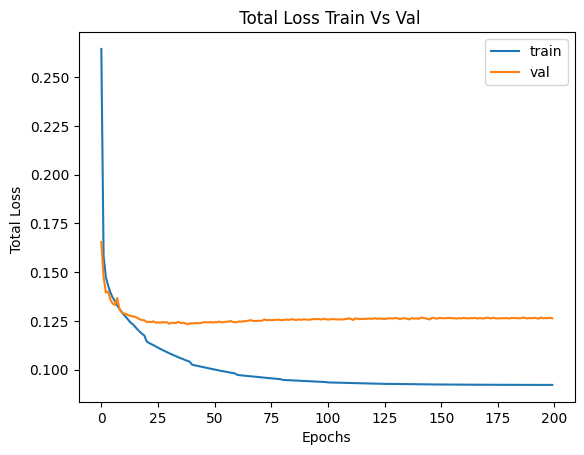

In [48]:
plt.figure()
plt.plot(total_losses_RIR_G_train,label='train')
plt.plot(total_losses_RIR_G_val,label='val')
plt.legend()
plt.title(" Total Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()

Text(0, 0.5, 'Pixel Loss ')

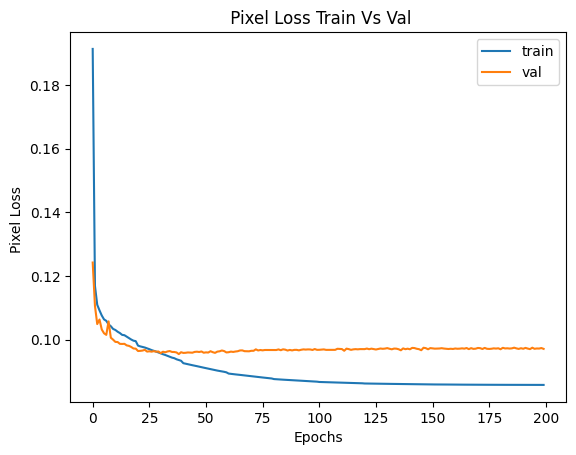

In [49]:
plt.figure()
plt.plot(losses_pixel_train,label='train')
plt.plot(losses_pixel_val,label='val')
plt.legend()
plt.title(" Pixel Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Pixel Loss ")

Text(0, 0.5, 'Perceptual Loss ')

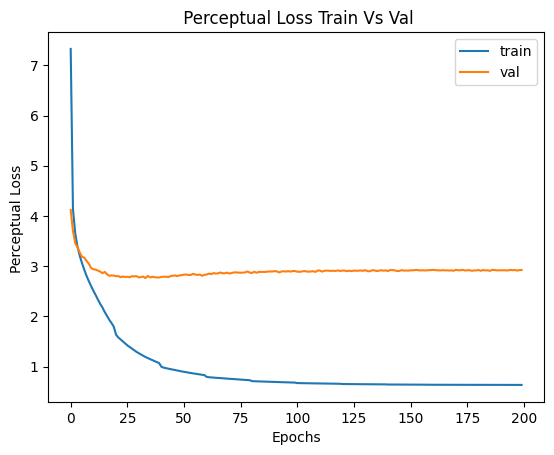

In [50]:
plt.figure()
plt.plot(losses_perceptual_train,label='train')
plt.plot(losses_perceptual_val,label='val')
plt.legend()
plt.title(" Perceptual Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Perceptual Loss ")

In [51]:
# #* Model's ie. Generator and Discriminator Initialization :

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_device(0)

gen=RIRG(
    in_channel=1,
    out_channel=1,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)

gen.load_state_dict(torch.load("gen_250.pth"))

vgg19_feature_extractor=VGG19.features[:35]

ON_OFF_Grad(vgg19_feature_extractor,'OFF')

gen.to(device)
vgg19_feature_extractor.to(device)

#* Optimizer Initialization and Loss function's

optimizer_gen=torch.optim.Adam(
    gen.parameters(),
    lr=1e-5,
    betas=(0.9,0.999)
    )


scheduler=torch.optim.lr_scheduler.StepLR(
    optimizer=optimizer_gen,
    step_size=20,
    gamma=0.5
)


#* training and validation loss list and EPOCHs Initialization
EPOCHS=50

#^ Generator Parameters :
total_losses_RIR_G_train=list()
total_losses_RIR_G_val=list()

losses_pixel_train=list()
losses_pixel_val=list()

losses_perceptual_train=list()
losses_perceptual_val=list()


#* for each EPOCH 

for epoch in range(1,EPOCHS+1):
    
    #&--------------------------------- RIR-G (Generator ) Training :-----------------------------------------

    #^ freezing the Dis and unfreezing the Gen.
    gen.train()

    #* iterating on all batches :
    running_total_loss_RIR_G_train=0.0
    running_loss_pixel_train=0.0
    running_loss_perceptual_train=0.0

    for LR_Images,HR_Images in train_loader:

        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

        #^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        #^ forward pass :
        
        SR_Images=gen(LR_Images) 

        #^ Loss Calculation : 4 type of loss :

        #^ 1.Pixel Loss :
        
        loss_pixel_train_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
        running_loss_pixel_train+=loss_pixel_train_batch.item()

        #^ 2.Perceptual Loss :

        loss_perceptual_train_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                        vgg19_feature_extractor=vgg19_feature_extractor,device=device)
        
        running_loss_perceptual_train+=loss_perceptual_train_batch.item()

        #^ Total Loss :

        total_loss_RIR_G_train_batch=loss_pixel_train_batch  + (loss_perceptual_train_batch * 0.05)

        running_total_loss_RIR_G_train+=total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        #^ Weight Updating of RIR-G

        optimizer_gen.step()

    

    total_loss_RIR_G_train=running_total_loss_RIR_G_train/len(train_loader)
    loss_pixel_train=running_loss_pixel_train/len(train_loader)
    loss_perceptual_train=running_loss_perceptual_train/len(train_loader)

    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)

    #* -------------------------------------- Validation ------------------------------------------------------
    gen.eval()

    with torch.no_grad():

        running_total_loss_RIR_G_val=0.0
        running_loss_pixel_val=0.0
        running_loss_perceptual_val=0.0

        #^ for each batch in the validation loader :
        for LR_Images,HR_Images in val_loader:

            LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

            #* forward pass of generator  :

            SR_Images=gen(LR_Images)

            #* Loss Calculation :

            #& RIR-G loss :

            #^ 1.Pixel Loss :
            
            loss_pixel_val_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
            running_loss_pixel_val+=loss_pixel_val_batch.item()

            #^ 2.Perceptual Loss :

            loss_perceptual_val_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                            vgg19_feature_extractor=vgg19_feature_extractor,device=device)
            
            running_loss_perceptual_val+=loss_perceptual_val_batch.item()


            #^ Total Loss :

            total_loss_RIR_G_val_batch= loss_pixel_val_batch  + ( loss_perceptual_val_batch * 0.05)
            
            running_total_loss_RIR_G_val+=total_loss_RIR_G_val_batch.item()


    total_loss_RIR_G_val=running_total_loss_RIR_G_val/len(val_loader)
    loss_pixel_val=running_loss_pixel_val/len(val_loader)
    loss_perceptual_val=running_loss_perceptual_val/len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)


    #^ ----------------------------------------- Saving Image Per Epochs -----------------------------------------------
    with torch.no_grad():

        LR_Images,HR_Images=next(iter(val_loader))
        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
        SR_Images=gen(LR_Images)

        SR_Images,LR_Images,HR_Images=SR_Images.to('cpu'),LR_Images.to('cpu'),HR_Images.to('cpu')

        save_MRI_images(
            LR_Images[0][0],
            SR_Images[0][0],
            HR_Images[0][0],
            title1='LR',
            title2='SR',
            title3='HR',
            image_name=f'/{epoch}.png',
            fold='AgainPretrain_Images2'
        )


    #* Update the learning rate after a epoch:
    scheduler.step()

    print(f'Epoch : {epoch}/{EPOCHS} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |')
    


Epoch : 1/50 
		 | Training Generator Total_loss : 0.11578696966171265 , Validation Generator Total_loss : 0.23004851567334142 |
Epoch : 2/50 
		 | Training Generator Total_loss : 0.11231451473637685 , Validation Generator Total_loss : 0.22947667616194692 |
Epoch : 3/50 
		 | Training Generator Total_loss : 0.1103707051861769 , Validation Generator Total_loss : 0.23042805801177846 |
Epoch : 4/50 
		 | Training Generator Total_loss : 0.10899502107265915 , Validation Generator Total_loss : 0.2300488396451391 |
Epoch : 5/50 
		 | Training Generator Total_loss : 0.10794045583906967 , Validation Generator Total_loss : 0.23080279035814877 |
Epoch : 6/50 
		 | Training Generator Total_loss : 0.10710635895668062 , Validation Generator Total_loss : 0.2299760248640488 |
Epoch : 7/50 
		 | Training Generator Total_loss : 0.10640389067150637 , Validation Generator Total_loss : 0.22997974886976438 |
Epoch : 8/50 
		 | Training Generator Total_loss : 0.10582053022725242 , Validation Generator Total_

C:\Users\sejal\AppData\Local\Temp\ipykernel_14508\1329127354.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes=plt.subplots(1,3,figsize=(20,20))


Epoch : 20/50 
		 | Training Generator Total_loss : 0.10154997622534664 , Validation Generator Total_loss : 0.23071672253567596 |


C:\Users\sejal\AppData\Local\Temp\ipykernel_14508\1329127354.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


Epoch : 21/50 
		 | Training Generator Total_loss : 0.10121458061913183 , Validation Generator Total_loss : 0.2311789532159937 |
Epoch : 22/50 
		 | Training Generator Total_loss : 0.10109346325018767 , Validation Generator Total_loss : 0.2313901722945016 |
Epoch : 23/50 
		 | Training Generator Total_loss : 0.10096737129220576 , Validation Generator Total_loss : 0.2310587476039755 |
Epoch : 24/50 
		 | Training Generator Total_loss : 0.10083226328973831 , Validation Generator Total_loss : 0.23218183373582774 |
Epoch : 25/50 
		 | Training Generator Total_loss : 0.1007127573431682 , Validation Generator Total_loss : 0.23200811420021386 |
Epoch : 26/50 
		 | Training Generator Total_loss : 0.10057828063840296 , Validation Generator Total_loss : 0.23146964686697927 |
Epoch : 27/50 
		 | Training Generator Total_loss : 0.10045802243737015 , Validation Generator Total_loss : 0.23195330130642858 |
Epoch : 28/50 
		 | Training Generator Total_loss : 0.1003390088169051 , Validation Generator 

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [52]:
torch.save(gen.state_dict(),'gen_300.pth')

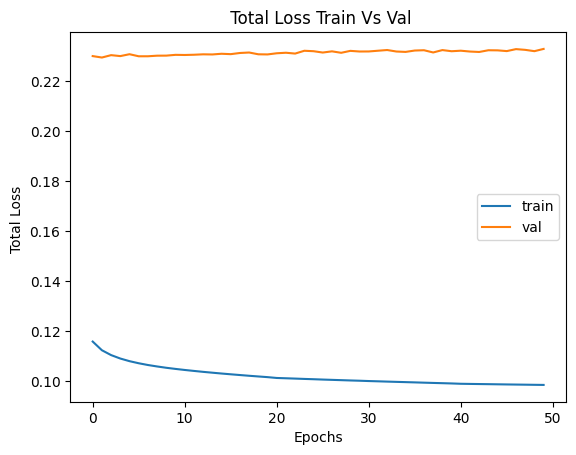

In [53]:
plt.figure()
plt.plot(total_losses_RIR_G_train,label='train')
plt.plot(total_losses_RIR_G_val,label='val')
plt.legend()
plt.title(" Total Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()

# **2.GAN Training :**

#### **Loading the Pretrain Generator :**

In [60]:
gen=RIRG(
    in_channel=1,
    out_channel=1,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)

gen.load_state_dict(torch.load('gen_200.pth'))

<All keys matched successfully>

In [61]:

dis=Rad(params)

In [64]:
# #* Model's ie. Generator and Discriminator Initialization :

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_device(0)


vgg19_feature_extractor=VGG19.features[:35]

ON_OFF_Grad(vgg19_feature_extractor,'OFF')

gen.to(device)
dis.to(device)
vgg19_feature_extractor.to(device)

#* Optimizer Initialization and Loss function's

optimizer_gen=torch.optim.Adam(
    gen.parameters(),
    lr=1e-4,
    betas=(0.5,0.999)
    )

optimizer_dis=torch.optim.Adam(
    dis.parameters(),
    lr=1e-7,
    betas=(0.5,0.99)
)

# LAMBDA=0.006
# GAMMA=1
# BETA=2e-9
# ETA=5e-3

LAMBDA=1.0
GAMMA=0.01
BETA=1e-8
ETA=0.001

totalVariationLoss=TotalVariation().to(device)


#* training and validation loss list and EPOCHs Initialization
EPOCHS=200

#^ Generator Parameters :
total_losses_RIR_G_train=list()
total_losses_RIR_G_val=list()

losses_pixel_train=list()
losses_pixel_val=list()

losses_perceptual_train=list()
losses_perceptual_val=list()

losses_adversarial_train=list()
losses_adversarial_val=list()

losses_totalVariation_train=list()
losses_totalVariation_val=list()


#^ Discriminator Parameters :

losses_RaD_train=list()
losses_RaD_val=list()



#* for each EPOCH 

for epoch in range(1,EPOCHS+1):
    
    #* -------------------------------- Training ----------------------------------------
    
    #&----------------- ---------------Training of RAD : -----------------------------------

    #^ freezing the Gen and unfreezing the Dis.

    gen.eval()
    dis.train()
    ON_OFF_Grad(gen,"OFF")
    ON_OFF_Grad(dis,"ON")
    running_loss_RaD_train=0.0

    #* iterating on all batches :

    for LR_Images,HR_Images in train_loader:

        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

        #^ optimizer_dis : gradient clear
        optimizer_dis.zero_grad()

        #^ forward pass :
        #* 1. Gen
        with torch.no_grad():
            SR_Images=gen(LR_Images) 
        
        #* 2. Dis

        sr_output=dis(SR_Images)
        hr_output=dis(HR_Images)

        #^ Loss Calculation :

        loss_RaD_train_batch= RaDLossFun(HR_Output=hr_output,SR_Output=sr_output,device=device)

        running_loss_RaD_train+=loss_RaD_train_batch.item()

        # ^ Gradient Calculation for RaD
        loss_RaD_train_batch.backward()

        #^ Weight Updating of RaD.

        optimizer_dis.step()


    loss_RaD_train=running_loss_RaD_train / len(train_loader)

    losses_RaD_train.append(loss_RaD_train)
    
    #&------------------------- RIR-G (Generator ) Training :---------------------------------

    #^ freezing the Dis and unfreezing the Gen.
    gen.train()
    dis.eval()
    ON_OFF_Grad(gen,"ON")
    ON_OFF_Grad(dis,"OFF")

    #* iterating on all batches :
    running_total_loss_RIR_G_train=0.0
    running_loss_pixel_train=0.0
    running_loss_perceptual_train=0.0
    running_loss_adversarial_train=0.0
    running_loss_totalVariation_train=0.0

    for LR_Images,HR_Images in train_loader:

        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

        #^ optimizer_dis : gradient clear
        optimizer_gen.zero_grad()

        #^ forward pass :

        #* 1. Gen
        
        SR_Images=gen(LR_Images) 
        
        #* 2. Dis


        sr_output=dis(SR_Images)
        hr_output=dis(HR_Images)


        #^ Loss Calculation : 4 type of loss :

        #^ 1.Pixel Loss :
        
        loss_pixel_train_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
        running_loss_pixel_train+=loss_pixel_train_batch.item()

        #^ 2.Perceptual Loss :

        loss_perceptual_train_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                        vgg19_feature_extractor=vgg19_feature_extractor,device=device)
        
        running_loss_perceptual_train+=loss_perceptual_train_batch.item()

        #^ 3.Adversarial Loss :

        loss_adversarial_train_batch=RIRGAdversarialLoss(HR_Output=hr_output,SR_Output=sr_output,device=device)

        running_loss_adversarial_train+=loss_adversarial_train_batch.item()

        #^ 4. TotalVariation Loss :

        loss_totalVariation_train_batch=RIRTotalVariation(SR_Images,totalVariationLoss,device)

        running_loss_totalVariation_train+=loss_totalVariation_train_batch.item()

        #^ Total Loss :

        total_loss_RIR_G_train_batch=(loss_pixel_train_batch * LAMBDA) + (loss_perceptual_train_batch*GAMMA) + (loss_adversarial_train_batch * ETA )+ (loss_totalVariation_train_batch * BETA)
        running_total_loss_RIR_G_train+=total_loss_RIR_G_train_batch.item()

        # ^ Gradient Calculation for RIR-G
        total_loss_RIR_G_train_batch.backward()

        #^ Weight Updating of RIR-G

        optimizer_gen.step()

    

    total_loss_RIR_G_train=running_total_loss_RIR_G_train/len(train_loader)
    loss_pixel_train=running_loss_pixel_train/len(train_loader)
    loss_perceptual_train=running_loss_perceptual_train/len(train_loader)
    loss_adversarial_train=running_loss_adversarial_train/len(train_loader)
    loss_totalVariation_train=running_loss_totalVariation_train/len(train_loader)


    total_losses_RIR_G_train.append(total_loss_RIR_G_train)
    losses_pixel_train.append(loss_pixel_train)
    losses_perceptual_train.append(loss_perceptual_train)
    losses_adversarial_train.append(loss_adversarial_train)
    losses_totalVariation_train.append(loss_totalVariation_train)


    #* -------------------------------------- Validation ------------------------------------------------------

    with torch.no_grad():

        running_loss_RaD_val=0.0

        running_total_loss_RIR_G_val=0.0
        running_loss_pixel_val=0.0
        running_loss_perceptual_val=0.0
        running_loss_adversarial_val=0.0
        running_loss_totalVariation_val=0.0

        #^ for each batch in the validation loader :
        for LR_Images,HR_Images in val_loader:

            LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)

            #* forward pass of generator  :

            SR_Images=gen(LR_Images)

            #* forward pass of discriminator :

            sr_output=dis(SR_Images)
            hr_output=dis(HR_Images)

            #* Loss Calculation :

            # & RaD Loss :

            loss_RaD_val_batch=RaDLossFun(HR_Output=hr_output,SR_Output=sr_output,device=device)
            running_loss_RaD_val+=loss_RaD_val_batch.item()

            #& RIR-G loss :

            #^ 1.Pixel Loss :
            
            loss_pixel_val_batch=RIRPixelLoss(HR_Images=HR_Images,SR_Images=SR_Images)
            running_loss_pixel_val+=loss_pixel_val_batch.item()

            #^ 2.Perceptual Loss :

            loss_perceptual_val_batch=RIRPerceptualLoss(SR_Images=SR_Images,HR_Images=HR_Images,
                                            vgg19_feature_extractor=vgg19_feature_extractor,device=device)
            
            running_loss_perceptual_val+=loss_perceptual_val_batch.item()

            #^ 3.Adversarial Loss :

            loss_adversarial_val_batch=RIRGAdversarialLoss(HR_Output=hr_output,SR_Output=sr_output,device=device)

            running_loss_adversarial_val+=loss_adversarial_val_batch.item()

            #^ 4. TotalVariation Loss :

            loss_totalVariation_val_batch=RIRTotalVariation(SR_Images,totalVariationLoss,device)

            running_loss_totalVariation_val+=loss_totalVariation_val_batch.item()

            #^ Total Loss :

            total_loss_RIR_G_val_batch=(loss_pixel_val_batch * LAMBDA) + (loss_perceptual_val_batch*GAMMA) + (loss_adversarial_val_batch* ETA )+ (loss_totalVariation_val_batch * BETA)
            
            running_total_loss_RIR_G_val+=total_loss_RIR_G_val_batch.item()


    loss_RaD_val=running_loss_RaD_val/len(val_loader)
    losses_RaD_val.append(loss_RaD_val)

    total_loss_RIR_G_val=running_total_loss_RIR_G_val/len(val_loader)
    loss_pixel_val=running_loss_pixel_val/len(val_loader)
    loss_perceptual_val=running_loss_perceptual_val/len(val_loader)
    loss_adversarial_val=running_loss_adversarial_val/len(val_loader)
    loss_totalVariation_val=running_loss_totalVariation_val/len(val_loader)

    total_losses_RIR_G_val.append(total_loss_RIR_G_val)
    losses_pixel_val.append(loss_pixel_val)
    losses_perceptual_val.append(loss_perceptual_val)
    losses_adversarial_val.append(loss_adversarial_val)
    losses_totalVariation_val.append(loss_totalVariation_val)


    with torch.no_grad():

        LR_Images,HR_Images=next(iter(val_loader))
        LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
        SR_Images=gen(LR_Images)

        SR_Images,LR_Images,HR_Images=SR_Images.to('cpu'),LR_Images.to('cpu'),HR_Images.to('cpu')

        save_MRI_images(
            LR_Images[0][0],
            SR_Images[0][0],
            HR_Images[0][0],
            title1='LR',
            title2='SR',
            title3='HR',
            image_name=f'{epoch}',
            fold='GANTraining_Images'

        )


    print(f'Epoch : {epoch}/{EPOCHS} \n\t\t | Training Generator Total_loss : {total_loss_RIR_G_train} , Validation Generator Total_loss : {total_loss_RIR_G_val} |'
                                    f'\n\t\t | Training Discriminator Loss   : {loss_RaD_train}  , Validation Discriminator Loss : {loss_RaD_val} |' )
    



Epoch : 1/200 
		 | Training Generator Total_loss : 0.10851663279571513 , Validation Generator Total_loss : 0.13466003652790498 |
		 | Training Discriminator Loss   : 1.3721911658102006  , Validation Discriminator Loss : 1.3816544927399734 |
Epoch : 2/200 
		 | Training Generator Total_loss : 0.10693166239747107 , Validation Generator Total_loss : 0.13309694942215394 |
		 | Training Discriminator Loss   : 1.3657502337559453  , Validation Discriminator Loss : 1.3747660456032589 |
Epoch : 3/200 
		 | Training Generator Total_loss : 0.10594780419045674 , Validation Generator Total_loss : 0.1320113556395317 |
		 | Training Discriminator Loss   : 1.36135317115133  , Validation Discriminator Loss : 1.3752800863364647 |
Epoch : 4/200 
		 | Training Generator Total_loss : 0.10530993391646505 , Validation Generator Total_loss : 0.12706201857533947 |
		 | Training Discriminator Loss   : 1.3538880721846622  , Validation Discriminator Loss : 1.3672333215845043 |
Epoch : 5/200 
		 | Training Genera

C:\Users\sejal\AppData\Local\Temp\ipykernel_12144\1329127354.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes=plt.subplots(1,3,figsize=(20,20))


Epoch : 20/200 
		 | Training Generator Total_loss : 0.09844890738855293 , Validation Generator Total_loss : 0.12689182778884625 |
		 | Training Discriminator Loss   : 1.2376227701650753  , Validation Discriminator Loss : 1.3082639431131298 |


C:\Users\sejal\AppData\Local\Temp\ipykernel_12144\1329127354.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


Epoch : 21/200 
		 | Training Generator Total_loss : 0.09790993308715983 , Validation Generator Total_loss : 0.12831742573401023 |
		 | Training Discriminator Loss   : 1.2266633370791926  , Validation Discriminator Loss : 1.3004107475280762 |
Epoch : 22/200 
		 | Training Generator Total_loss : 0.09746111802327861 , Validation Generator Total_loss : 0.12777548732942548 |
		 | Training Discriminator Loss   : 1.221864081394952  , Validation Discriminator Loss : 1.3051646927307392 |
Epoch : 23/200 
		 | Training Generator Total_loss : 0.09765166876666835 , Validation Generator Total_loss : 0.131103471178433 |
		 | Training Discriminator Loss   : 1.2157448639493507  , Validation Discriminator Loss : 1.2969669822988839 |
Epoch : 24/200 
		 | Training Generator Total_loss : 0.09744158611178144 , Validation Generator Total_loss : 0.12829022854566574 |
		 | Training Discriminator Loss   : 1.2104707872435483  , Validation Discriminator Loss : 1.2940506955672955 |
Epoch : 25/200 
		 | Training G

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [65]:
torch.save(gen.state_dict(),'Gan_Gen1_85.pth')


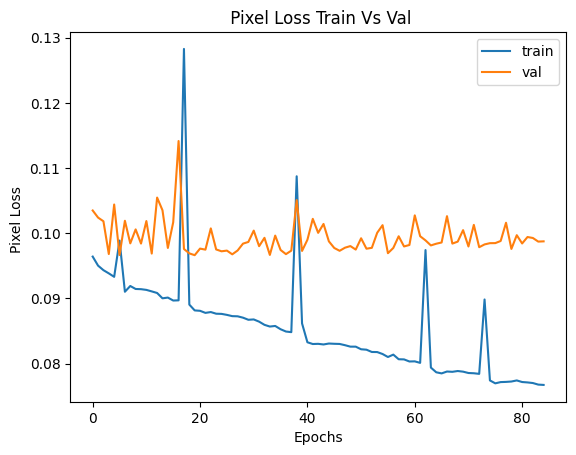

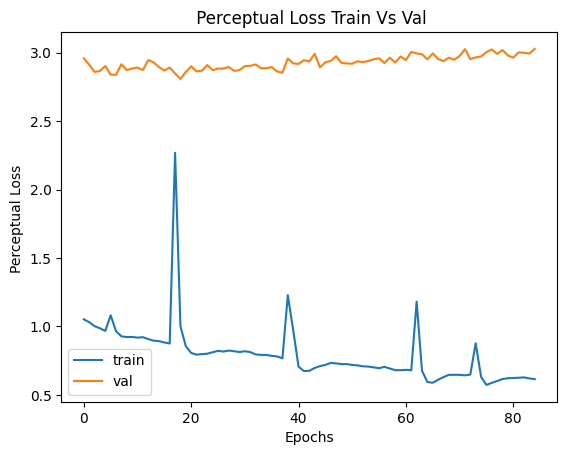

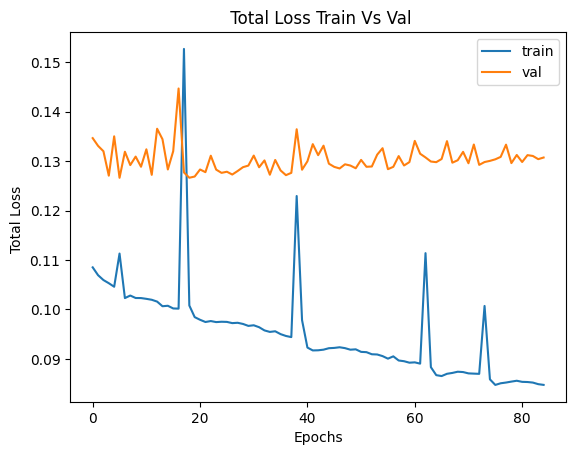

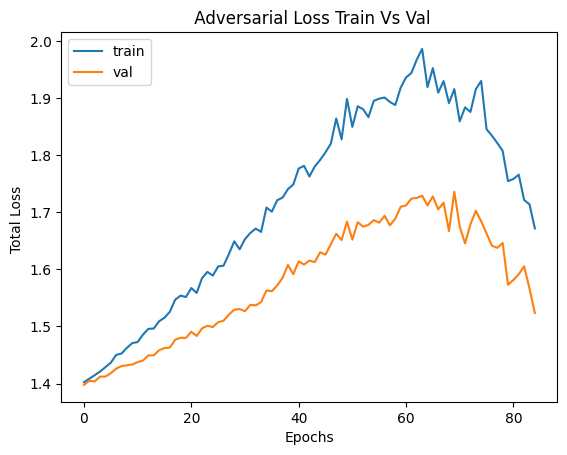

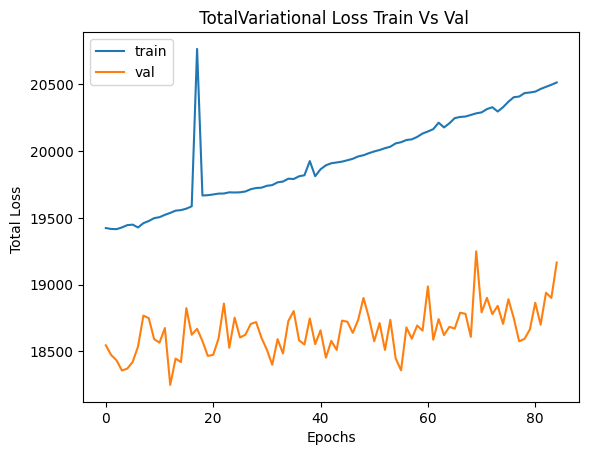

In [67]:
plt.figure()
plt.plot(losses_pixel_train,label='train')
plt.plot(losses_pixel_val,label='val')
plt.legend()
plt.title(" Pixel Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Pixel Loss ")


plt.figure()
plt.plot(losses_perceptual_train,label='train')
plt.plot(losses_perceptual_val,label='val')
plt.legend()
plt.title(" Perceptual Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Perceptual Loss ")



plt.figure()
plt.plot(total_losses_RIR_G_train,label='train')
plt.plot(total_losses_RIR_G_val,label='val')
plt.legend()
plt.title(" Total Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()


plt.figure()
plt.plot(losses_adversarial_train,label='train')
plt.plot(losses_adversarial_val,label='val')
plt.legend()
plt.title(" Adversarial Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()


plt.figure()
plt.plot(losses_totalVariation_train,label='train')
plt.plot(losses_totalVariation_val,label='val')
plt.legend()
plt.title(" TotalVariational Loss Train Vs Val")
plt.xlabel("Epochs")
plt.ylabel("Total Loss ")
plt.show()

# **Testing Images :**

In [36]:
gen=RIRG(
    in_channel=1,
    out_channel=1,
    in_RIR_block_channel=64,
    kernel_size_in_out_layer=9,
    kerne_size_RIR_block=3,
    no_of_RIR_Block=8,
    no_of_ERes_block=5,
    sub_PixelLayer_channel=256,
    alpha=0.2,
    scale=2   
)

gen.load_state_dict(torch.load('Gan_Gen1_85.pth'))

<All keys matched successfully>

In [48]:
LR_Images,HR_Images=next(iter(test_loader))
print(f'Shape of Batch Test LR_Images :{LR_Images.shape}')
print(f'Shape of Batch Test HR_Images :{HR_Images.shape}')

Shape of Batch Test LR_Images :torch.Size([16, 1, 32, 32])
Shape of Batch Test HR_Images :torch.Size([16, 1, 128, 128])


<Figure size 640x480 with 0 Axes>

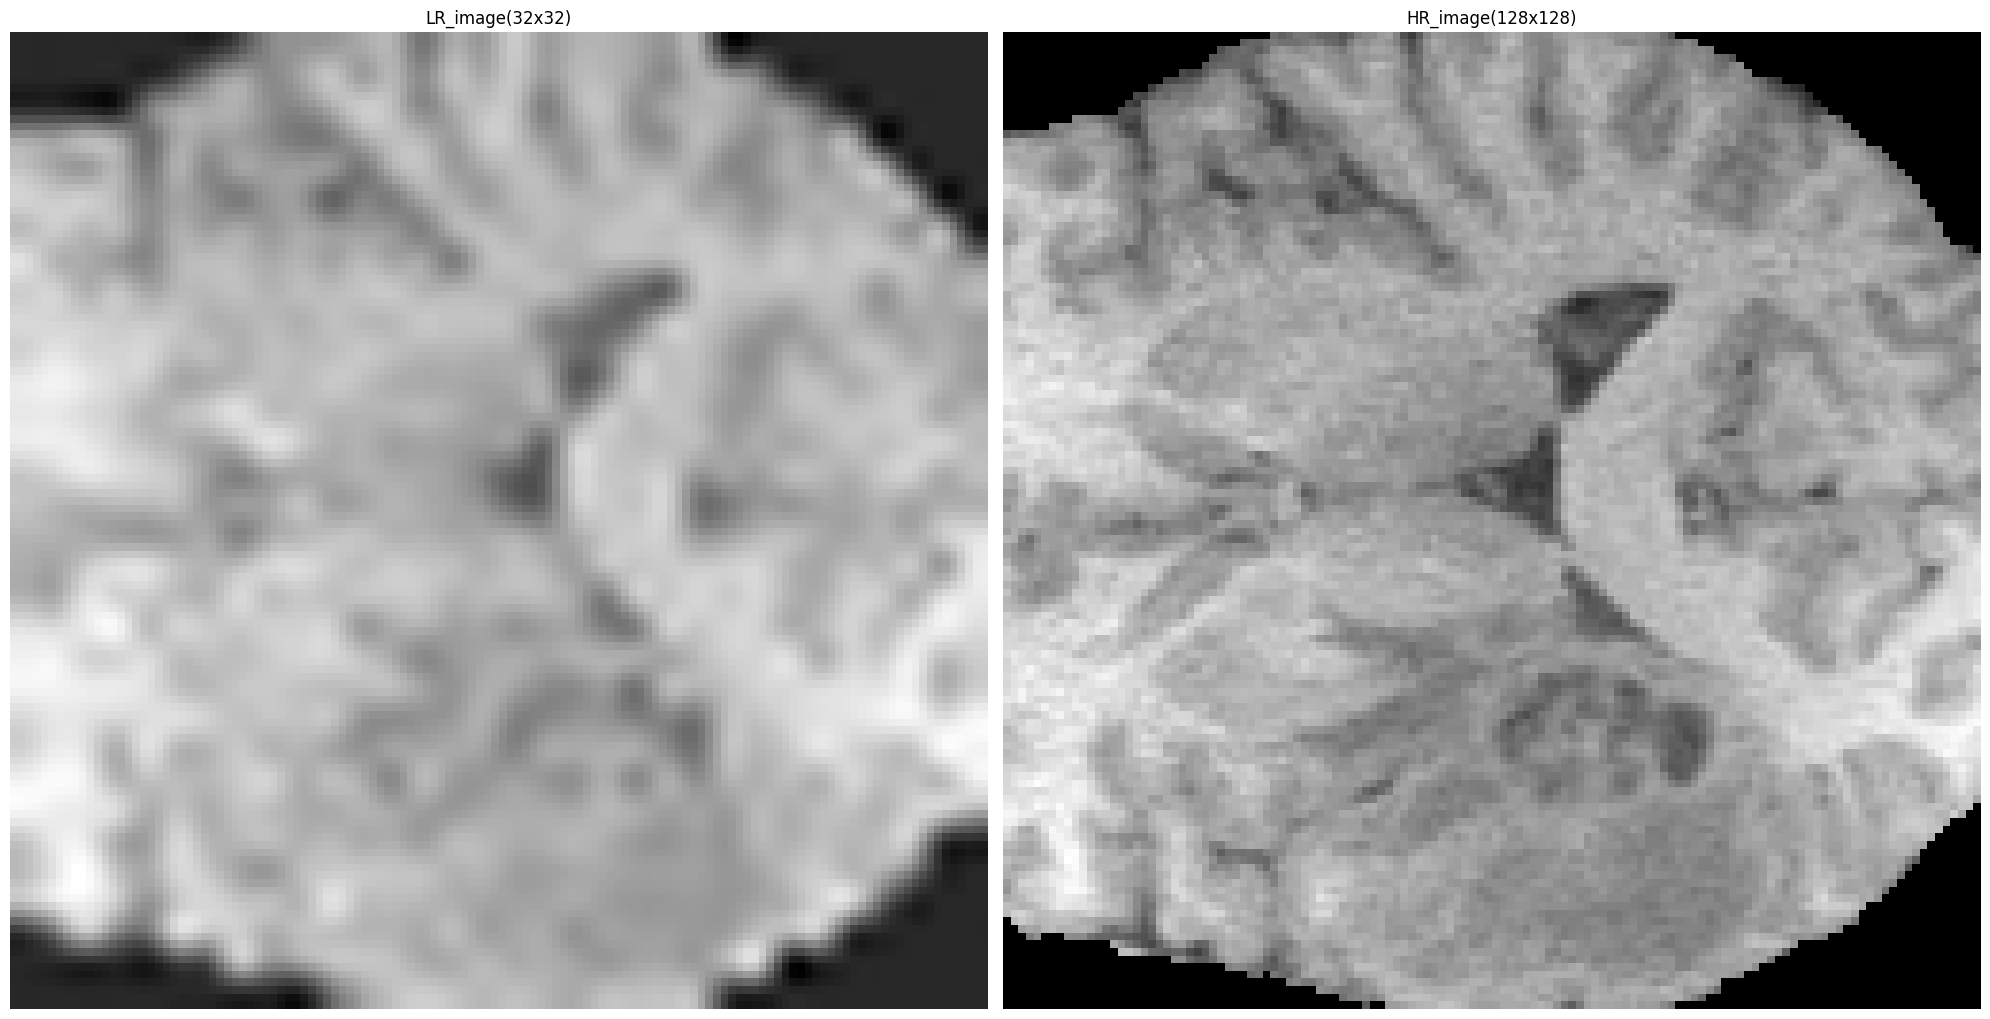

In [52]:
show_MRI_images(LR_Images[0][0],HR_Images[0][0],'LR_image(32x32)','HR_image(128x128)')

In [55]:
with torch.no_grad():
    SR_Images=gen(LR_Images)

In [56]:
save_MRI_images(
    LR_Images[0][0],
    SR_Images[0][0],
    HR_Images[0][0],
    'LR',
    'SR',
    'HR',
    'test',
    './'
)

<Figure size 640x480 with 0 Axes>

In [58]:
for SR_Image in SR_Images:
    print(SR_Image.shape)

torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])
torch.Size([1, 128, 128])


In [60]:
# #* loop for storing the Test Images int th folder Test_Images :

name=1
for LR_Images,HR_Images in test_loader:
    
    with torch.no_grad():

        SR_Images=gen(LR_Images)
        
        for index, SR_Image in enumerate(SR_Images):

            LR_image=LR_Images[index]
            HR_image=HR_Images[index]

            save_MRI_images(
                image1=LR_image[0],
                image2=SR_Image[0],
                image3=HR_image[0],
                title1='LR(32x32)',
                title2='SR(128X128)',
                title3='HR(128X128)',
                image_name=f'{name}',
                fold='Test_Images'
            )
            name+=1


C:\Users\sejal\AppData\Local\Temp\ipykernel_12104\3751840226.py:121: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes=plt.subplots(1,3,figsize=(20,20))
C:\Users\sejal\AppData\Local\Temp\ipykernel_12104\3751840226.py:119: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

# **Evaluation Metrics**

## **PSNR** 
    - (ie.for single image)

In [ ]:
# HR_Images[0].shape[0],HR_Images[0].shape[1],HR_Images[0].shape[2]
# HR_Images[0].shape[0]*HR_Images[0].shape[1]*HR_Images[0].shape[2]
# np.array(10*torch.log10(((1/(((HR_Images-SR_Images)**2).sum(dim=(1,2,3))/(128*128))))))
# ((HR_Images-SR_Images)**2).sum(dim=(1,2,3),keepdim=True).reshape(14,1)/(HR_Images[0].shape[0]*HR_Images[0].shape[1]*HR_Images[0].shape[2])
# torch.nn.functional.mse_loss(HR_Images,SR_Images)

(1, 128, 128)

In [245]:
def PSNR(SR_Images,HR_Images):

    SR_Images=(SR_Images+1)/2
    HR_Images=(HR_Images+1)/2
    C,H,W=SR_Images[0].shape
    total_pixel_per_image=C*H*W
    psnr=10*torch.log10(((1/(((HR_Images-SR_Images)**2).sum(dim=(1,2,3))/(total_pixel_per_image)))))

    return np.array(psnr)


In [260]:
PSNR(SR_Images,HR_Images)

array([19.419582, 19.36977 , 19.702713, 19.759693, 18.221413, 17.58329 ,
       18.61596 , 18.519749, 20.717585, 19.859037, 19.381538, 19.74479 ,
       19.791409, 20.607964], dtype=float32)

## **Covariance :**

In [238]:

Ux=SR_Images.mean(dim=(1,2,3),keepdim=True).resize(14,1)
Uy=HR_Images.mean(dim=(1,2,3),keepdim=True).resize(14,1)
torch.stack([SR_Images,HR_Images]).shape
torch.cov(torch.stack((SR_Images[0].flatten(),HR_Images[0].flatten())),correction=1)
(Xi_X)=SR_Images-SR_Images.mean(dim=(1,2,3),keepdim=True)
(Yi_Y)=HR_Images-HR_Images.mean(dim=(1,2,3),keepdim=True)

print(f'Xi_X Shape : {Xi_X.shape}')
print(f'Yi_Y Shape : {Yi_Y.shape}')
(Xi_X*Yi_Y).shape
covar_SR_HR=((Xi_X*Yi_Y).sum(dim=(1,2,3))/(128*128)).reshape(14,1)
covar_SR_HR
var_x=SR_Images.var(dim=(1,2,3)).reshape(14,1)
var_y=HR_Images.var(dim=(1,2,3)).reshape(14,1)
var_x
term1=((Ux*Uy*2) + 2)/((Ux**2) + (Uy**2) + 2)
term1
SR_Images.var(dim=(1,2,3))
SR_Images.std(dim=(1,2,3))**2
term2=(covar_SR_HR + 2)/(var_x +var_y + 2 ) 
(term2*term1).reshape(1,14)
var_x
(Xi_X**2).mean(dim=(1,2,3),keepdim=True).reshape(14,1)

Xi_X Shape : torch.Size([14, 1, 128, 128])
Yi_Y Shape : torch.Size([14, 1, 128, 128])


c:\Users\sejal\.conda\envs\mldl-nlp\lib\site-packages\torch\_tensor.py:1025: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


tensor([[0.2635],
        [0.1477],
        [0.1842],
        [0.1982],
        [0.2055],
        [0.1217],
        [0.1099],
        [0.1577],
        [0.1452],
        [0.2235],
        [0.2743],
        [0.1624],
        [0.1816],
        [0.1767]])

In [248]:
def SSIM(SR_Images,HR_Images,K1:float,K2: float):

    B,C,H,W=SR_Images.shape
    Ux=SR_Images.mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    Uy=HR_Images.mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    
    (Xi_X)=SR_Images-(SR_Images.mean(dim=(1,2,3),keepdim=True))
    (Yi_Y)=HR_Images-(HR_Images.mean(dim=(1,2,3),keepdim=True))

    covar_x_y=((Xi_X*Yi_Y).sum(dim=(1,2,3))/(C*H*W)).reshape(B,1)

    var_x=(Xi_X**2).mean(dim=(1,2,3),keepdim=True).reshape(B,1)
    var_y=(Yi_Y**2).mean(dim=(1,2,3),keepdim=True).reshape(B,1)

    term1=((Ux*Uy*2) + K1)/((Ux**2) + (Uy**2) + K1)

    term2=(covar_x_y + K2)/(var_x +var_y + K2 ) 

    ssim=(term1*term2).reshape(B) 

    return np.array(ssim)


In [249]:
SSIM(SR_Images,HR_Images,0.01,0.2)

array([0.6233777 , 0.6898589 , 0.6611933 , 0.651736  , 0.6485254 ,
       0.7095581 , 0.72192687, 0.6759538 , 0.6911629 , 0.64288884,
       0.6161696 , 0.67632395, 0.6595689 , 0.6676858 ], dtype=float32)

In [259]:
# #* finding the statistical parameter of Images to find the image quality
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gen=gen.to(device)


psnr_list=np.array([])
ssim_list=np.array([])

for LR_Images,HR_Images in test_loader:

    LR_Images,HR_Images=LR_Images.to(device),HR_Images.to(device)
    with torch.no_grad():
        SR_Images=gen(LR_Images)

    #* find the psnr of each images and append to psnr list :

    SR_Images,HR_Images=SR_Images.to('cpu'),HR_Images.to('cpu')
    psnr_list_temp=PSNR(SR_Images,HR_Images)
    ssim_list_temp=SSIM(SR_Images,HR_Images,0.01,0.02)

    psnr_list=np.append(psnr_list,psnr_list_temp)

    ssim_list=np.append(ssim_list,ssim_list_temp)
    

In [258]:
psnr_list.shape

(814,)

In [274]:
Mean=psnr_list.mean()
Var=psnr_list.var()
Std=psnr_list.std()
Min=psnr_list.min()
Max=psnr_list.max()
delta=Max-Min

print("*"*25)
print( "RIRGAN_Metric_PSNR :")
print(f" Mean  ↑ : {Mean:.2f}")
print(f' Var   ↓ : {Var:.2f}')
print(f' Std   ↓ : {Std:.2f}')
print(f' Min   - : {Min:.2f}')
print(f' Max   - : {Max:.2f}')
print(f' Delta ↓ : {delta:.2f}')



Mean=ssim_list.mean()
Var=ssim_list.var()
Std=ssim_list.std()
Min=ssim_list.min()
Max=ssim_list.max()
delta=Max-Min


print("*"*25)
print( "RIRGAN_Metric_SSIM :")
print(f" Mean  ↑ : {Mean:.5f}")
print(f' Var   ↓ : {Var:.5f}')
print(f' Std   ↓ : {Std:.5f}')
print(f' Min   - : {Min:.5f}')
print(f' Max   - : {Max:.5f}')
print(f' Delta ↓ : {delta:.5f}')

print("*"*25) 


*************************
RIRGAN_Metric_PSNR :
 Mean  ↑ : 19.58
 Var   ↓ : 1.45
 Std   ↓ : 1.21
 Min   - : 13.88
 Max   - : 22.55
 Delta ↓ : 8.67
*************************
RIRGAN_Metric_SSIM :
 Mean  ↑ : 0.49163
 Var   ↓ : 0.00001
 Std   ↓ : 0.00350
 Min   - : 0.47998
 Max   - : 0.49907
 Delta ↓ : 0.01909
*************************
